# Net2Brain 3D NN (NSD)

## extracting Data, RDM, and RSA

In [10]:
# CONFIGURATION
import os

from pathlib import Path

nsd_path = Path("../Algonauts23_shared_Net2Brain")

stimuli_path = nsd_path / "images"

print("NSD dataset:", nsd_path)
print("Stimuli path:", stimuli_path)
print("Images exist:", stimuli_path.exists())
print("Number of images:", len(list(stimuli_path.glob("*.png"))))

NSD dataset: ..\Algonauts23_shared_Net2Brain
Stimuli path: ..\Algonauts23_shared_Net2Brain\images
Images exist: True
Number of images: 872


In [3]:
# Paths for RSA

nsd_path = Path("../Algonauts23_shared_Net2Brain")

# All subjects
subject_paths = sorted(nsd_path.glob("subj*"))

# Brain RDM paths
subject_rdm_paths = {
    subject.name: subject / "rdms"
    for subject in subject_paths
}

print("NSD dataset:", nsd_path)

print("\nSubjects:")
for subject in subject_paths:
    print(subject.name)

print("\nRDM paths:")
for subject, rdm_path in subject_rdm_paths.items():
    print(subject, "->", rdm_path)

NSD dataset: ..\Algonauts23_shared_Net2Brain

Subjects:
subj01
subj02
subj03
subj04
subj05
subj06
subj07
subj08

RDM paths:
subj01 -> ..\Algonauts23_shared_Net2Brain\subj01\rdms
subj02 -> ..\Algonauts23_shared_Net2Brain\subj02\rdms
subj03 -> ..\Algonauts23_shared_Net2Brain\subj03\rdms
subj04 -> ..\Algonauts23_shared_Net2Brain\subj04\rdms
subj05 -> ..\Algonauts23_shared_Net2Brain\subj05\rdms
subj06 -> ..\Algonauts23_shared_Net2Brain\subj06\rdms
subj07 -> ..\Algonauts23_shared_Net2Brain\subj07\rdms
subj08 -> ..\Algonauts23_shared_Net2Brain\subj08\rdms


In [4]:
## create the two NSD RSA folders

import numpy as np
from pathlib import Path
from scipy.spatial.distance import squareform

nsd_path = Path("../Algonauts23_shared_Net2Brain")

# Output folders for RSA
nsd_visual_rdm_path = Path("NSD_visual_RDMs")
nsd_ppa_rdm_path = Path("NSD_PPA_RDMs")

nsd_visual_rdm_path.mkdir(exist_ok=True)
nsd_ppa_rdm_path.mkdir(exist_ok=True)

# ROIs for the visual cortex analysis
visual_rois = [
    "V1d",
    "V1v",
    "V2d",
    "V2v",
    "V3d",
    "V3v",
    "hV4"
]

# Function to combine the 8 subjects for ONE ROI + ONE hemisphere
def create_grouped_rdm(roi, hemisphere, output_folder):

    subject_rdms = []

    for subject_num in range(1, 9):

        file = (
            nsd_path
            / f"subj{subject_num:02d}"
            / "rdms"
            / f"{roi}_{hemisphere}_subj{subject_num:02d}.npy"
        )

        condensed_rdm = np.load(file)

        # 379756 values -> 872 x 872 RDM
        square_rdm = squareform(condensed_rdm)

        subject_rdms.append(square_rdm)

    # subjects × images × images
    subject_rdms = np.stack(subject_rdms)

    # Save in Net2Brain-compatible NPZ format
    output_file = output_folder / f"{roi}_{hemisphere}.npz"

    np.savez(
        output_file,
        rdm=subject_rdms
    )


# Create visual ROI RDMs
for roi in visual_rois:
    for hemisphere in ["lh", "rh"]:
        create_grouped_rdm(
            roi,
            hemisphere,
            nsd_visual_rdm_path
        )


# Create PPA RDMs
for hemisphere in ["lh", "rh"]:
    create_grouped_rdm(
        "PPA",
        hemisphere,
        nsd_ppa_rdm_path
    )


print("Visual RSA files:")
for file in sorted(nsd_visual_rdm_path.glob("*.npz")):
    print(file.name)

print("\nPPA RSA files:")
for file in sorted(nsd_ppa_rdm_path.glob("*.npz")):
    print(file.name)

Visual RSA files:
hV4_lh.npz
hV4_rh.npz
V1d_lh.npz
V1d_rh.npz
V1v_lh.npz
V1v_rh.npz
V2d_lh.npz
V2d_rh.npz
V2v_lh.npz
V2v_rh.npz
V3d_lh.npz
V3d_rh.npz
V3v_lh.npz
V3v_rh.npz

PPA RSA files:
PPA_lh.npz
PPA_rh.npz


In [5]:
from net2brain.feature_extraction import FeatureExtractor

models_3d = [
    "curvature",
    "edge_occlusion",
    "reshading",
    "depth",
    "normal",
    "segment_unsup25d"
]

layers = ["relu1", "layer4"]

for model in models_3d:

    print("\n" + "=" * 60)
    print(f"Processing 3D model: {model}")
    print("=" * 60)

    fx = FeatureExtractor(
        model=model,
        netset="Taskonomy",
        device="cuda"
    )

    feature_path = f"{model}_feats_NSD_relu1_layer4"

    fx.extract(
        data_path=stimuli_path,
        save_path=feature_path,
        layers_to_extract=layers
    )

    print(f"Finished feature extraction: {model}")

print("\nAll 3D feature extraction completed.")


Processing 3D model: curvature


Processing files: 100%|██████████| 872/872 [00:27<00:00, 31.54it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 872/872 [00:05<00:00, 150.59it/s]


Finished feature extraction: curvature

Processing 3D model: edge_occlusion


...

Finished feature extraction: normal

Processing 3D model: segment_unsup25d


Processing files: 100%|██████████| 872/872 [00:26<00:00, 33.43it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 872/872 [00:04<00:00, 195.78it/s]


Finished feature extraction: segment_unsup25d

All 3D feature extraction completed.


In [6]:
from net2brain.rdm_creation import RDMCreator

creator = RDMCreator(
    verbose=True,
    device="cuda"
)

for model_name in models_3d:

    feature_path = f"{model_name}_feats_NSD_relu1_layer4"
    rdm_path = f"{model_name}_RDMs_NSD_relu1_layer4"

    print(f"\nCreating RDMs for: {model_name}")

    creator.create_rdms(
        feature_path=feature_path,
        save_path=rdm_path,
        save_format="npz"
    )

    print(f"Finished: {model_name}")

print("\nAll 3D RDMs completed.")


Creating RDMs for: curvature


c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

Finished: curvature

Creating RDMs for: edge_occlusion


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

...

Finished: depth

Creating RDMs for: normal


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

Finished: normal

Creating RDMs for: segment_unsup25d


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

Finished: segment_unsup25d

All 3D RDMs completed.


In [7]:
from pathlib import Path

for model in models_3d:

    rdm_path = Path(f"{model}_RDMs_NSD_relu1_layer4")

    print(f"\n{model}:")

    for layer in ["relu1", "layer4"]:

        file = rdm_path / f"RDM_{layer}.npz"

        print(
            f"  {layer}:",
            "OK" if file.exists() else "MISSING"
        )


curvature:
  relu1: OK
  layer4: OK

edge_occlusion:
  relu1: OK
  layer4: OK

reshading:
  relu1: OK
  layer4: OK

depth:
  relu1: OK
  layer4: OK

normal:
  relu1: OK
  layer4: OK

segment_unsup25d:
  relu1: OK
  layer4: OK


### Z-scoring and combining RDMs

In [9]:
# Z-SCORE FUNCTION
import numpy as np

def zs(v):
    return (v - v.mean()) / v.std()

In [10]:
# LOAD + Z-SCORE ALL 12 RDMs
from pathlib import Path

zscored_rdms = {}

for model in models_3d:

    rdm_dir = Path(
        f"{model}_RDMs_NSD_relu1_layer4"
    )

    for layer in layers:

        rdm_file = rdm_dir / f"RDM_{layer}.npz"

        rdm = np.load(rdm_file)["rdm"]

        # Z-score the RDM
        rdm_z = zs(rdm)

        key = f"{model}_{layer}"

        zscored_rdms[key] = rdm_z

        print(
            f"{key:35s}",
            "original:", rdm.shape,
            "z-scored:", rdm_z.shape,
            "mean:", rdm_z.mean(),
            "std:", rdm_z.std()
        )

curvature_layer4                    original: (379756,) z-scored: (379756,) mean: -3.8573287e-09 std: 1.0
curvature_relu1                     original: (379756,) z-scored: (379756,) mean: 4.3394948e-08 std: 0.99999994
edge_occlusion_layer4               original: (379756,) z-scored: (379756,) mean: 2.6358414e-08 std: 1.0
edge_occlusion_relu1                original: (379756,) z-scored: (379756,) mean: 1.0446932e-07 std: 1.0
reshading_layer4                    original: (379756,) z-scored: (379756,) mean: 6.6860366e-08 std: 0.99999994
reshading_relu1                     original: (379756,) z-scored: (379756,) mean: -1.350065e-07 std: 0.9999999
depth_layer4                        original: (379756,) z-scored: (379756,) mean: -4.3716394e-08 std: 1.0
depth_relu1                         original: (379756,) z-scored: (379756,) mean: -1.4786427e-08 std: 1.0
normal_layer4                       original: (379756,) z-scored: (379756,) mean: -7.3932135e-08 std: 1.0
normal_relu1                   

In [11]:
# COMBINE ALL 6 TASKS × 2 LAYERS

rdm_parts = list(zscored_rdms.values())

combined_3d_rdm = np.mean(
    rdm_parts,
    axis=0
)

print("Number of RDMs combined:", len(rdm_parts))
print("Combined 3D RDM shape:", combined_3d_rdm.shape)
print("Combined mean:", combined_3d_rdm.mean())
print("Combined std:", combined_3d_rdm.std())

Number of RDMs combined: 12
Combined 3D RDM shape: (379756,)
Combined mean: 3.407307e-08
Combined std: 0.63010097


In [12]:
# SAVE COMBINED 3D RDM
combined_3d_dir = Path(
    "Taskonomy_3D_Combined_RDM_NSD"
)

combined_3d_dir.mkdir(
    exist_ok=True
)

np.savez(
    combined_3d_dir / "RDM_3D_combined.npz",
    rdm=combined_3d_rdm
)

print(
    "Saved:",
    combined_3d_dir / "RDM_3D_combined.npz"
)

Saved: Taskonomy_3D_Combined_RDM_NSD\RDM_3D_combined.npz


In [14]:
# Check combined 3D RDM

combined_3d = np.load(
    "Taskonomy_3D_Combined_RDM_NSD/RDM_3D_combined.npz"
)["rdm"]

print("Combined 3D RDM:")
print("Shape:", combined_3d.shape)
print("Expected:", 872 * 871 // 2)
print("Mean:", combined_3d.mean())
print("Std:", combined_3d.std())
print("Finite:", np.isfinite(combined_3d).all())

Combined 3D RDM:
Shape: (379756,)
Expected: 379756
Mean: 3.407307e-08
Std: 0.63010097
Finite: True


### Brain RDM inspection and loading

In [16]:
models_3d = [
    "curvature",
    "edge_occlusion",
    "reshading",
    "depth",
    "normal",
    "segment_unsup25d"
]

layers = ["layer4", "relu1"]

print("Models:", models_3d)
print("Layers:", layers)

Models: ['curvature', 'edge_occlusion', 'reshading', 'depth', 'normal', 'segment_unsup25d']
Layers: ['layer4', 'relu1']


In [17]:
from pathlib import Path
import numpy as np

taskonomy_rdms = {}

for model in models_3d:
    rdm_dir = Path(f"{model}_RDMs_NSD_relu1_layer4")

    layer4 = np.load(
        rdm_dir / "RDM_layer4.npz"
    )["rdm"]

    relu1 = np.load(
        rdm_dir / "RDM_relu1.npz"
    )["rdm"]

    taskonomy_rdms[model] = {
        "layer4": layer4,
        "relu1": relu1
    }

    print(
        model,
        "| layer4:", layer4.shape,
        "| relu1:", relu1.shape
    )

curvature | layer4: (379756,) | relu1: (379756,)
edge_occlusion | layer4: (379756,) | relu1: (379756,)
reshading | layer4: (379756,) | relu1: (379756,)
depth | layer4: (379756,) | relu1: (379756,)
normal | layer4: (379756,) | relu1: (379756,)
segment_unsup25d | layer4: (379756,) | relu1: (379756,)


### Two-predictor regression

In [18]:
from sklearn.linear_model import LinearRegression

model = "curvature"
subject = "subj01"
brain_roi = "hV4_lh"

# Taskonomy predictors
rdm_layer4 = taskonomy_rdms[model]["layer4"]
rdm_relu1 = taskonomy_rdms[model]["relu1"]

# Brain RDM
brain_file = (
    nsd_path
    / subject
    / "rdms"
    / f"{brain_roi}_{subject}.npy"
)

brain_rdm = np.load(brain_file)

print("layer4:", rdm_layer4.shape)
print("relu1:", rdm_relu1.shape)
print("brain:", brain_rdm.shape)

layer4: (379756,)
relu1: (379756,)
brain: (379756,)


In [19]:
# Two-predictor regression:
# brain RDM ~ layer4 RDM + relu1 RDM

X = np.column_stack([
    rdm_layer4,
    rdm_relu1
])

y = brain_rdm

reg = LinearRegression()
reg.fit(X, y)

r2 = reg.score(X, y)

n = len(y)
p = 2

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Model:", model)
print("Subject:", subject)
print("ROI:", brain_roi)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)
print("Coefficients:", reg.coef_)

Model: curvature
Subject: subj01
ROI: hV4_lh
R²: 0.0005557012949781726
Adjusted R²: 0.0005504376404515954
Coefficients: [ 0.02834517 -0.00594634]


In [20]:
roi_files = {
    "V1": [
        "V1d_lh",
        "V1d_rh",
        "V1v_lh",
        "V1v_rh"
    ],
    "V2": [
        "V2d_lh",
        "V2d_rh",
        "V2v_lh",
        "V2v_rh"
    ],
    "V3": [
        "V3d_lh",
        "V3d_rh",
        "V3v_lh",
        "V3v_rh"
    ],
    "V4": [
        "hV4_lh",
        "hV4_rh"
    ],
    "PPA": [
        "PPA_lh",
        "PPA_rh"
    ]
}

for group, rois in roi_files.items():
    print(group, ":", rois)

V1 : ['V1d_lh', 'V1d_rh', 'V1v_lh', 'V1v_rh']
V2 : ['V2d_lh', 'V2d_rh', 'V2v_lh', 'V2v_rh']
V3 : ['V3d_lh', 'V3d_rh', 'V3v_lh', 'V3v_rh']
V4 : ['hV4_lh', 'hV4_rh']
PPA : ['PPA_lh', 'PPA_rh']


In [21]:
import pandas as pd
from sklearn.linear_model import LinearRegression

regression_results = []

for model in models_3d:

    print(f"\nRunning: {model}")

    rdm_layer4 = taskonomy_rdms[model]["layer4"]
    rdm_relu1 = taskonomy_rdms[model]["relu1"]

    X = np.column_stack([
        rdm_layer4,
        rdm_relu1
    ])

    for subject_num in range(1, 9):

        subject = f"subj{subject_num:02d}"

        for roi_group, roi_names in roi_files.items():

            for roi_name in roi_names:

                brain_file = (
                    nsd_path
                    / subject
                    / "rdms"
                    / f"{roi_name}_{subject}.npy"
                )

                if not brain_file.exists():
                    print("Missing:", brain_file)
                    continue

                y = np.load(brain_file)

                if y.shape != (379756,):
                    print(
                        "Unexpected shape:",
                        brain_file,
                        y.shape
                    )
                    continue

                reg = LinearRegression()
                reg.fit(X, y)

                r2 = reg.score(X, y)

                n = len(y)
                p = 2

                adjusted_r2 = (
                    1
                    - (1 - r2)
                    * (n - 1)
                    / (n - p - 1)
                )

                regression_results.append({
                    "Model": model,
                    "Subject": subject,
                    "ROI_Group": roi_group,
                    "ROI": roi_name,
                    "R2": r2,
                    "Adjusted_R2": adjusted_r2,
                    "Beta_layer4": reg.coef_[0],
                    "Beta_relu1": reg.coef_[1]
                })

    print(f"Finished: {model}")


Running: curvature
Finished: curvature

Running: edge_occlusion
Finished: edge_occlusion

Running: reshading
Finished: reshading

Running: depth
Finished: depth

Running: normal
Finished: normal

Running: segment_unsup25d
Finished: segment_unsup25d


In [22]:
regression_df = pd.DataFrame(regression_results)

print(regression_df.shape)
print(regression_df.head())

regression_df.to_csv(
    "Taskonomy_3D_two_predictor_regression_NSD.csv",
    index=False
)

print("Saved:")
print("Taskonomy_3D_two_predictor_regression_NSD.csv")

(768, 8)
       Model Subject ROI_Group     ROI        R2  Adjusted_R2  Beta_layer4  \
0  curvature  subj01        V1  V1d_lh  0.001580     0.001575     0.048946   
1  curvature  subj01        V1  V1d_rh  0.001117     0.001112     0.045544   
2  curvature  subj01        V1  V1v_lh  0.003626     0.003621     0.075501   
3  curvature  subj01        V1  V1v_rh  0.004507     0.004502     0.085924   
4  curvature  subj01        V2  V2d_lh  0.000445     0.000440     0.034561   

   Beta_relu1  
0   -0.008242  
1   -0.013143  
2   -0.012337  
3   -0.010555  
4   -0.013295  
Saved:
Taskonomy_3D_two_predictor_regression_NSD.csv


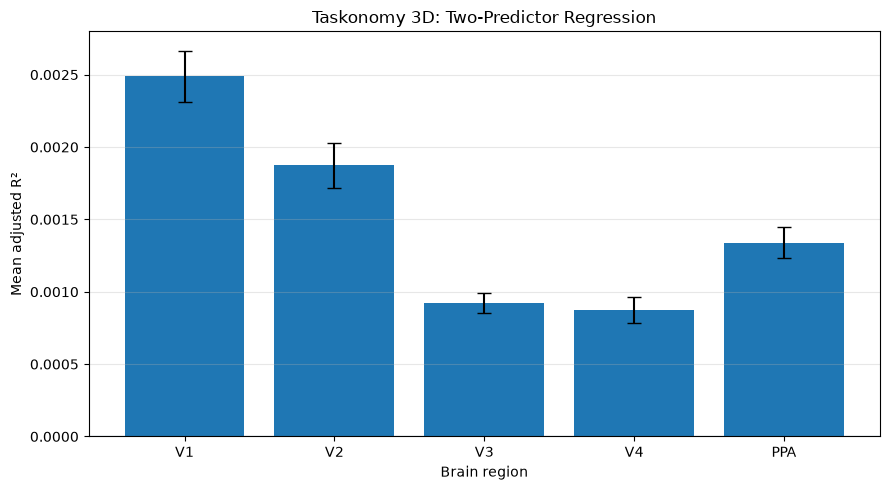

               mean       std  count       SEM
ROI_Group                                     
V1         0.002489  0.002460    192  0.000178
V2         0.001873  0.002130    192  0.000154
V3         0.000922  0.000941    192  0.000068
V4         0.000872  0.000881     96  0.000090
PPA        0.001339  0.001064     96  0.000109


In [24]:
#Plot the two-predictor regression results
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load regression results
df = pd.read_csv("Taskonomy_3D_two_predictor_regression_NSD.csv")

# Average adjusted R² across models and subjects
roi_order = ["V1", "V2", "V3", "V4", "PPA"]

summary = (
    df.groupby("ROI_Group")["Adjusted_R2"]
    .agg(["mean", "std", "count"])
    .reindex(roi_order)
)

# Calculate standard error
summary["SEM"] = summary["std"] / np.sqrt(summary["count"])

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    summary.index,
    summary["mean"],
    yerr=summary["SEM"],
    capsize=5
)

ax.axhline(0, linewidth=0.8)
ax.set_xlabel("Brain region")
ax.set_ylabel("Mean adjusted R²")
ax.set_title("Taskonomy 3D: Two-Predictor Regression")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "Taskonomy_3D_two_predictor_regression_NSD_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(summary)

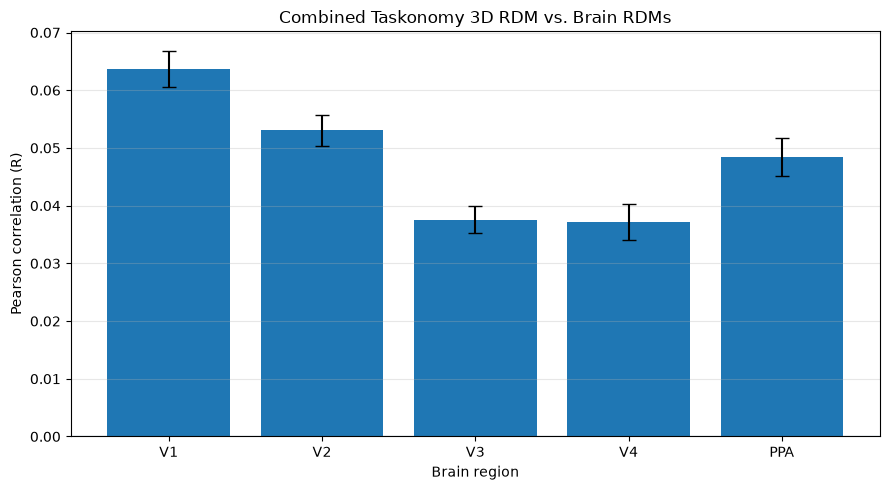

               mean       std  count       SEM
ROI_Group                                     
V1         0.063727  0.008864      8  0.003134
V2         0.053029  0.007432      8  0.002627
V3         0.037593  0.006539      8  0.002312
V4         0.037220  0.008747      8  0.003093
PPA        0.048452  0.009165      8  0.003240


In [25]:
# Plot the combined 3D RDM
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Load combined 3D RDM
combined = np.load(
    "Taskonomy_3D_Combined_RDM_NSD/RDM_3D_combined.npz"
)["rdm"]

# Brain RDM directory
brain_path = Path("../Algonauts23_shared_Net2Brain")

roi_groups = {
    "V1": ["V1d", "V1v"],
    "V2": ["V2d", "V2v"],
    "V3": ["V3d", "V3v"],
    "V4": ["hV4"],
    "PPA": ["PPA"]
}

results = []

for subject_num in range(1, 9):
    subject = f"subj{subject_num:02d}"
    rdm_dir = brain_path / subject / "rdms"

    for group, rois in roi_groups.items():
        for roi in rois:
            for hemisphere in ["lh", "rh"]:
                filename = f"{roi}_{hemisphere}_{subject}.npy"
                filepath = rdm_dir / filename

                if not filepath.exists():
                    continue

                brain_rdm = np.load(filepath)

                if brain_rdm.shape != combined.shape:
                    raise ValueError(
                        f"Shape mismatch: {filepath}: "
                        f"{brain_rdm.shape} vs {combined.shape}"
                    )

                r = pearsonr(combined, brain_rdm).statistic

                results.append({
                    "Subject": subject,
                    "ROI_Group": group,
                    "ROI": f"{roi}_{hemisphere}",
                    "R": r
                })

rsa_df = pd.DataFrame(results)
rsa_df.to_csv(
    "Taskonomy_3D_Combined_RSA_NSD.csv",
    index=False
)

# Average ROI/hemisphere correlations within each subject.
subject_means = (
    rsa_df.groupby(["Subject", "ROI_Group"])["R"]
    .mean()
    .reset_index()
)

# Average across subjects and calculate SEM.
summary = (
    subject_means.groupby("ROI_Group")["R"]
    .agg(["mean", "std", "count"])
    .reindex(["V1", "V2", "V3", "V4", "PPA"])
)

summary["SEM"] = summary["std"] / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    summary.index,
    summary["mean"],
    yerr=summary["SEM"],
    capsize=5
)

ax.axhline(0, linewidth=0.8)
ax.set_xlabel("Brain region")
ax.set_ylabel("Pearson correlation (R)")
ax.set_title("Combined Taskonomy 3D RDM vs. Brain RDMs")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "Taskonomy_3D_Combined_RSA_NSD_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(summary)

#### RSA

In [67]:
from net2brain.evaluations.rsa import RSA

# ---------------------------------------------------------
# TASKONOMY 3D MODELS
# ---------------------------------------------------------
models_3d = {
    "Curvature": "./curvature_RDMs_NSD_relu1_layer4",
    "Edge Occlusion": "./edge_occlusion_RDMs_NSD_relu1_layer4",
    "Reshading": "./reshading_RDMs_NSD_relu1_layer4",
    "Depth": "./depth_RDMs_NSD_relu1_layer4",
    "Normal": "./normal_RDMs_NSD_relu1_layer4",
    "Segment Unsup25D": "./segment_unsup25d_RDMs_NSD_relu1_layer4"
}

# Store results
visual_results = {}
ppa_results = {}

# ---------------------------------------------------------
# RUN RSA FOR ALL 6 MODELS
# ---------------------------------------------------------
for model_name, model_rdms in models_3d.items():

    print(f"\n========== {model_name} ==========")

    # -------------------------
    # Visual cortex RSA
    # -------------------------
    visual_evaluation = RSA(
        model_rdms,
        "./NSD_visual_RDMs",
        model_name=f"Taskonomy {model_name}"
    )

    df_visual = visual_evaluation.evaluate()

    visual_results[model_name] = df_visual

    print(f"Visual RSA: {df_visual.shape}")
    display(df_visual)

    # -------------------------
    # PPA RSA
    # -------------------------
    ppa_evaluation = RSA(
        model_rdms,
        "./NSD_PPA_RDMs",
        model_name=f"Taskonomy {model_name}"
    )

    df_ppa = ppa_evaluation.evaluate()

    ppa_results[model_name] = df_ppa

    print(f"PPA RSA: {df_ppa.shape}")
    display(df_ppa)

print("\n========== ALL RSA FINISHED ==========")


========== Curvature ==========
Visual RSA: (28, 10)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) hV4_lh,(0) RDM_layer4.npz,Taskonomy Curvature,0.000050,0.050469,"[0.00011058785290211045, 5.898279400851539e-05...",0.004584,0.000012,0.099376,0.262878
1,(0) hV4_lh,(1) RDM_relu1.npz,Taskonomy Curvature,0.000023,0.022759,"[4.8035626472710523e-05, 6.01277980571026e-06,...",0.020750,0.000008,0.099376,0.262878
2,(1) hV4_rh,(0) RDM_layer4.npz,Taskonomy Curvature,0.000081,0.081069,"[0.00023615876836329932, 0.0001576746171538654...",0.026569,0.000029,0.099353,0.262107
3,(1) hV4_rh,(1) RDM_relu1.npz,Taskonomy Curvature,0.000051,0.050965,"[0.0001407622840434477, 4.585236585217626e-05,...",0.013914,0.000016,0.099353,0.262107
4,(2) V1d_lh,(0) RDM_layer4.npz,Taskonomy Curvature,0.000180,0.102021,"[0.000515120461501194, 9.785660135492383e-05, ...",0.027207,0.000065,0.176120,0.335863
5,(2) V1d_lh,(1) RDM_relu1.npz,Taskonomy Curvature,0.000093,0.052879,"[0.0003051795840270626, 2.3669186365813132e-05...",0.024886,0.000033,0.176120,0.335863
6,(3) V1d_rh,(0) RDM_layer4.npz,Taskonomy Curvature,0.000265,0.155243,"[0.00039293999043775907, 0.0002097850677913903...",0.000311,0.000040,0.170802,0.331561
7,(3) V1d_rh,(1) RDM_relu1.npz,Taskonomy Curvature,0.000161,0.094072,"[0.00021221090890552428, 0.0001760674632129636...",0.000092,0.000020,0.170802,0.331561
8,(4) V1v_lh,(0) RDM_layer4.npz,Taskonomy Curvature,0.000695,0.376274,"[0.00146497821399961, 0.000279620914169863, 0....",0.003201,0.000158,0.184608,0.344487
9,(4) V1v_lh,(1) RDM_relu1.npz,Taskonomy Curvature,0.000461,0.249579,"[0.0009493485544019533, 0.0002823183766257657,...",0.001446,0.000091,0.184608,0.344487


PPA RSA: (4, 10)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) PPA_lh,(0) RDM_layer4.npz,Taskonomy Curvature,0.000112,0.066221,"[0.00010016111348567724, 0.0001090186009743984...",0.001205,0.000021,0.169846,0.329043
1,(0) PPA_lh,(1) RDM_relu1.npz,Taskonomy Curvature,0.000072,0.042673,"[4.112569458308593e-05, 0.00014077965177440203...",0.013747,0.000022,0.169846,0.329043
2,(1) PPA_rh,(0) RDM_layer4.npz,Taskonomy Curvature,0.000113,0.058966,"[8.495184647334745e-05, 0.00011124611276744948...",0.000403,0.000018,0.191527,0.349057
3,(1) PPA_rh,(1) RDM_relu1.npz,Taskonomy Curvature,0.000081,0.042249,"[6.928482665289558e-08, 0.0001369854180472165,...",0.007261,0.000022,0.191527,0.349057



========== Edge Occlusion ==========
Visual RSA: (28, 10)


...


========== Segment Unsup25D ==========
Visual RSA: (28, 10)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) hV4_lh,(0) RDM_layer4.npz,Taskonomy Segment Unsup25D,0.000533,0.536005,"[0.0008313103666686347, 0.00040088721870245746...",0.000153,0.000072,0.099376,0.262878
1,(0) hV4_lh,(1) RDM_relu1.npz,Taskonomy Segment Unsup25D,0.000840,0.844841,"[0.001303098671224507, 0.0005782283946039093, ...",0.000276,0.000125,0.099376,0.262878
2,(1) hV4_rh,(0) RDM_layer4.npz,Taskonomy Segment Unsup25D,0.000629,0.633384,"[0.0011255306208283024, 0.0004950824997684099,...",0.000340,0.000097,0.099353,0.262107
3,(1) hV4_rh,(1) RDM_relu1.npz,Taskonomy Segment Unsup25D,0.000969,0.974957,"[0.002079890042097097, 0.0007833941020086936, ...",0.000842,0.000174,0.099353,0.262107
4,(2) V1d_lh,(0) RDM_layer4.npz,Taskonomy Segment Unsup25D,0.001302,0.739337,"[0.0017062159119104199, 0.001719897087321068, ...",0.000156,0.000177,0.176120,0.335863
5,(2) V1d_lh,(1) RDM_relu1.npz,Taskonomy Segment Unsup25D,0.001555,0.882823,"[0.002044108675733113, 0.002099154631533544, 0...",0.000060,0.000182,0.176120,0.335863
6,(3) V1d_rh,(0) RDM_layer4.npz,Taskonomy Segment Unsup25D,0.001167,0.683406,"[0.0015549994418544528, 0.0012060007588363016,...",0.000156,0.000159,0.170802,0.331561
7,(3) V1d_rh,(1) RDM_relu1.npz,Taskonomy Segment Unsup25D,0.001177,0.688982,"[0.002162309602645042, 0.000985871934379845, 0...",0.000739,0.000207,0.170802,0.331561
8,(4) V1v_lh,(0) RDM_layer4.npz,Taskonomy Segment Unsup25D,0.002012,1.089935,"[0.002175872330483562, 0.001608963233413597, 0...",0.000010,0.000179,0.184608,0.344487
9,(4) V1v_lh,(1) RDM_relu1.npz,Taskonomy Segment Unsup25D,0.001910,1.034842,"[0.00189726062368115, 0.001752370819865536, 0....",0.000036,0.000207,0.184608,0.344487


PPA RSA: (4, 10)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) PPA_lh,(0) RDM_layer4.npz,Taskonomy Segment Unsup25D,0.001661,0.978210,"[0.0017040392229480555, 0.0017907752441007278,...",0.000994,0.000307,0.169846,0.329043
1,(0) PPA_lh,(1) RDM_relu1.npz,Taskonomy Segment Unsup25D,0.003199,1.883321,"[0.002278418512085598, 0.0029317545522514286, ...",0.003855,0.000755,0.169846,0.329043
2,(1) PPA_rh,(0) RDM_layer4.npz,Taskonomy Segment Unsup25D,0.001843,0.962051,"[0.002355042535631731, 0.0024037432246767675, ...",0.000368,0.000288,0.191527,0.349057
3,(1) PPA_rh,(1) RDM_relu1.npz,Taskonomy Segment Unsup25D,0.003510,1.832800,"[0.004680402674681533, 0.0037772823830502546, ...",0.000455,0.000568,0.191527,0.349057



========== ALL RSA FINISHED ==========


In [68]:
all_rsa_dfs = []

for model_name in models_3d:
    all_rsa_dfs.append(visual_results[model_name])
    all_rsa_dfs.append(ppa_results[model_name])

print("Total RSA DataFrames:", len(all_rsa_dfs))

Total RSA DataFrames: 12


## Evaluation

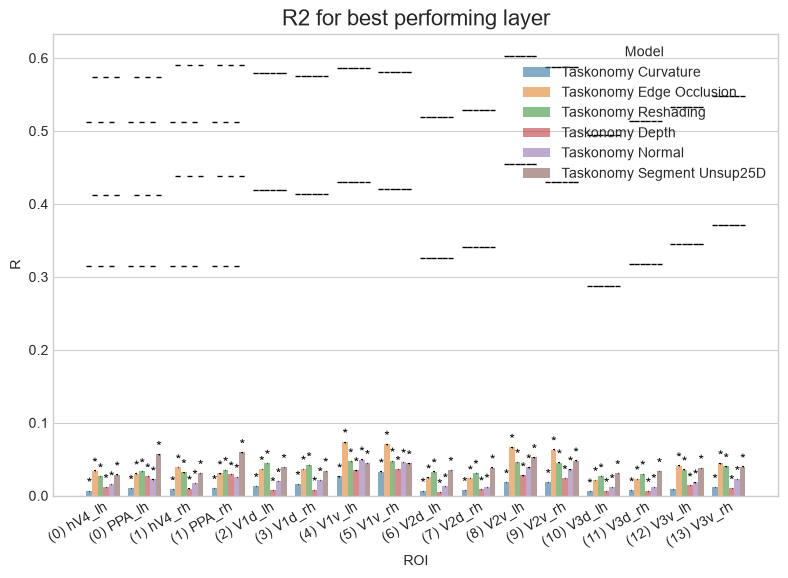

,ROI,Model,Layer,R
0,(0) hV4_lh,Taskonomy Curvature,(0) RDM_layer4.npz,0.007082
1,(0) PPA_lh,Taskonomy Curvature,(0) RDM_layer4.npz,0.010605
2,(0) hV4_lh,Taskonomy Edge Occlusion,(0) RDM_layer4.npz,0.034521
3,(0) PPA_lh,Taskonomy Edge Occlusion,(0) RDM_layer4.npz,0.030327
4,(0) hV4_lh,Taskonomy Reshading,(0) RDM_layer4.npz,0.026576
...,...,...,...,...
91,(13) V3v_rh,Taskonomy Edge Occlusion,(0) RDM_layer4.npz,0.044160
92,(13) V3v_rh,Taskonomy Reshading,(0) RDM_layer4.npz,0.040259
93,(13) V3v_rh,Taskonomy Depth,(1) RDM_relu1.npz,0.010601
94,(13) V3v_rh,Taskonomy Normal,(1) RDM_relu1.npz,0.023067


In [69]:
from net2brain.evaluations.plotting import Plotting
plotter = Plotting(all_rsa_dfs)

results_dataframe = plotter.plot(metric="R")

display(results_dataframe)

In [70]:
import pandas as pd
import re

def prepare_layer_dataframe(results_dict, dataset_name):
    layers_data = []

    for model_name, df in results_dict.items():

        for _, row in df.iterrows():

            # Keep the actual layer name
            layer = str(row["Layer"])

            # Convert layer to an ordered number:
            # relu1 = 1
            # layer4 = 4
            if "relu1" in layer.lower():
                layer_number = 1
            elif "layer4" in layer.lower():
                layer_number = 4
            else:
                layer_number = None

            layers_data.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Layer": layer,
                "Layer_Number": layer_number,
                "R": row.get("R"),
                "R2": row["R2"],
                "SEM": row["SEM"],
                "Significance": row["Significance"],
                "ROI": row["ROI"]
            })

    return pd.DataFrame(layers_data)


df_visual_layers = prepare_layer_dataframe(
    visual_results,
    "Visual"
)

df_ppa_layers = prepare_layer_dataframe(
    ppa_results,
    "PPA"
)

print("VISUAL:")
print(df_visual_layers.shape)
display(df_visual_layers.head())

print("\nPPA:")
print(df_ppa_layers.shape)
display(df_ppa_layers.head())

VISUAL:
(168, 9)


,Dataset,Model,Layer,Layer_Number,R,R2,SEM,Significance,ROI
0,Visual,Curvature,(0) RDM_layer4.npz,4,0.007082,0.000050,0.000012,0.004584,(0) hV4_lh
1,Visual,Curvature,(1) RDM_relu1.npz,1,0.004756,0.000023,0.000008,0.020750,(0) hV4_lh
2,Visual,Curvature,(0) RDM_layer4.npz,4,0.008975,0.000081,0.000029,0.026569,(1) hV4_rh
3,Visual,Curvature,(1) RDM_relu1.npz,1,0.007116,0.000051,0.000016,0.013914,(1) hV4_rh
4,Visual,Curvature,(0) RDM_layer4.npz,4,0.013404,0.000180,0.000065,0.027207,(2) V1d_lh



PPA:
(24, 9)


,Dataset,Model,Layer,Layer_Number,R,R2,SEM,Significance,ROI
0,PPA,Curvature,(0) RDM_layer4.npz,4,0.010605,0.000112,0.000021,0.001205,(0) PPA_lh
1,PPA,Curvature,(1) RDM_relu1.npz,1,0.008513,0.000072,0.000022,0.013747,(0) PPA_lh
2,PPA,Curvature,(0) RDM_layer4.npz,4,0.010627,0.000113,0.000018,0.000403,(1) PPA_rh
3,PPA,Curvature,(1) RDM_relu1.npz,1,0.008995,0.000081,0.000022,0.007261,(1) PPA_rh
4,PPA,Edge Occlusion,(0) RDM_layer4.npz,4,0.030327,0.000920,0.000130,0.000194,(0) PPA_lh


In [71]:
df_roi_layers = pd.concat(
    [
        df_visual_layers,
        df_ppa_layers
    ],
    ignore_index=True
)

df_roi_layers = df_roi_layers.sort_values(
    [
        "Dataset",
        "ROI",
        "Model",
        "Layer_Number"
    ]
).reset_index(drop=True)

print("Combined dataframe:", df_roi_layers.shape)

display(df_roi_layers.head(20))

Combined dataframe: (192, 9)


,Dataset,Model,Layer,Layer_Number,R,R2,SEM,Significance,ROI
0,PPA,Curvature,(1) RDM_relu1.npz,1,0.008513,0.000072,0.000022,0.013747,(0) PPA_lh
1,PPA,Curvature,(0) RDM_layer4.npz,4,0.010605,0.000112,0.000021,0.001205,(0) PPA_lh
2,PPA,Depth,(1) RDM_relu1.npz,1,0.026109,0.000682,0.000163,0.004103,(0) PPA_lh
3,PPA,Depth,(0) RDM_layer4.npz,4,0.026605,0.000708,0.000185,0.006444,(0) PPA_lh
4,PPA,Edge Occlusion,(1) RDM_relu1.npz,1,0.026431,0.000699,0.000104,0.000280,(0) PPA_lh
5,PPA,Edge Occlusion,(0) RDM_layer4.npz,4,0.030327,0.000920,0.000130,0.000194,(0) PPA_lh
6,PPA,Normal,(1) RDM_relu1.npz,1,0.020707,0.000429,0.000084,0.001437,(0) PPA_lh
7,PPA,Normal,(0) RDM_layer4.npz,4,0.022208,0.000493,0.000080,0.000453,(0) PPA_lh
8,PPA,Reshading,(1) RDM_relu1.npz,1,0.024763,0.000613,0.000106,0.000660,(0) PPA_lh
9,PPA,Reshading,(0) RDM_layer4.npz,4,0.033561,0.001126,0.000174,0.000339,(0) PPA_lh


In [72]:
def assign_roi_group(roi):
    roi = str(roi).lower()

    # V1
    if "v1d" in roi or "v1v" in roi:
        return "V1"

    # V2
    elif "v2d" in roi or "v2v" in roi:
        return "V2"

    # V3
    elif "v3d" in roi or "v3v" in roi:
        return "V3"

    # V4
    elif "hv4" in roi:
        return "V4"

    # PPA
    elif "ppa" in roi:
        return "PPA"

    else:
        return None


df_roi_layers["ROI_Group"] = (
    df_roi_layers["ROI"]
    .apply(assign_roi_group)
)

df_plot = df_roi_layers[
    df_roi_layers["ROI_Group"].isin(
        ["V1", "V2", "V3", "V4", "PPA"]
    )
].copy()

print("Plotting dataframe:", df_plot.shape)

display(
    df_plot[
        ["Dataset", "ROI", "ROI_Group", "Model", "Layer", "R"]
    ].head(20)
)

Plotting dataframe: (192, 10)


,Dataset,ROI,ROI_Group,Model,Layer,R
0,PPA,(0) PPA_lh,PPA,Curvature,(1) RDM_relu1.npz,0.008513
1,PPA,(0) PPA_lh,PPA,Curvature,(0) RDM_layer4.npz,0.010605
2,PPA,(0) PPA_lh,PPA,Depth,(1) RDM_relu1.npz,0.026109
3,PPA,(0) PPA_lh,PPA,Depth,(0) RDM_layer4.npz,0.026605
4,PPA,(0) PPA_lh,PPA,Edge Occlusion,(1) RDM_relu1.npz,0.026431
5,PPA,(0) PPA_lh,PPA,Edge Occlusion,(0) RDM_layer4.npz,0.030327
6,PPA,(0) PPA_lh,PPA,Normal,(1) RDM_relu1.npz,0.020707
7,PPA,(0) PPA_lh,PPA,Normal,(0) RDM_layer4.npz,0.022208
8,PPA,(0) PPA_lh,PPA,Reshading,(1) RDM_relu1.npz,0.024763
9,PPA,(0) PPA_lh,PPA,Reshading,(0) RDM_layer4.npz,0.033561


In [73]:
coverage = (
    df_plot
    .groupby(["Model", "Layer"])
    .size()
    .unstack(fill_value=0)
)

display(coverage)

Layer,(0) RDM_layer4.npz,(1) RDM_relu1.npz
Model,,
Curvature,16,16
Depth,16,16
Edge Occlusion,16,16
Normal,16,16
Reshading,16,16
Segment Unsup25D,16,16


In [74]:
df_plot_summary = (
    df_plot
    .groupby(
        [
            "Model",
            "ROI_Group",
            "Layer_Number"
        ]
    )["R"]
    .mean()
    .reset_index()
)

display(df_plot_summary)

,Model,ROI_Group,Layer_Number,R
0,Curvature,PPA,1,0.008754
1,Curvature,PPA,4,0.010616
2,Curvature,V1,1,0.016507
3,Curvature,V1,4,0.022289
4,Curvature,V2,1,0.007742
5,Curvature,V2,4,0.013085
6,Curvature,V3,1,0.005651
7,Curvature,V3,4,0.008609
8,Curvature,V4,1,0.005936
9,Curvature,V4,4,0.008028


In [75]:
df_plot_summary = (

    df_plot

    .groupby(
        [
            "Model",
            "ROI_Group",
            "Layer",
            "Layer_Number"
        ]
    )["R"]

    .mean()

    .reset_index()

)

display(df_plot_summary)

,Model,ROI_Group,Layer,Layer_Number,R
0,Curvature,PPA,(0) RDM_layer4.npz,4,0.010616
1,Curvature,PPA,(1) RDM_relu1.npz,1,0.008754
2,Curvature,V1,(0) RDM_layer4.npz,4,0.022289
3,Curvature,V1,(1) RDM_relu1.npz,1,0.016507
4,Curvature,V2,(0) RDM_layer4.npz,4,0.013085
5,Curvature,V2,(1) RDM_relu1.npz,1,0.007742
6,Curvature,V3,(0) RDM_layer4.npz,4,0.008609
7,Curvature,V3,(1) RDM_relu1.npz,1,0.005651
8,Curvature,V4,(0) RDM_layer4.npz,4,0.008028
9,Curvature,V4,(1) RDM_relu1.npz,1,0.005936


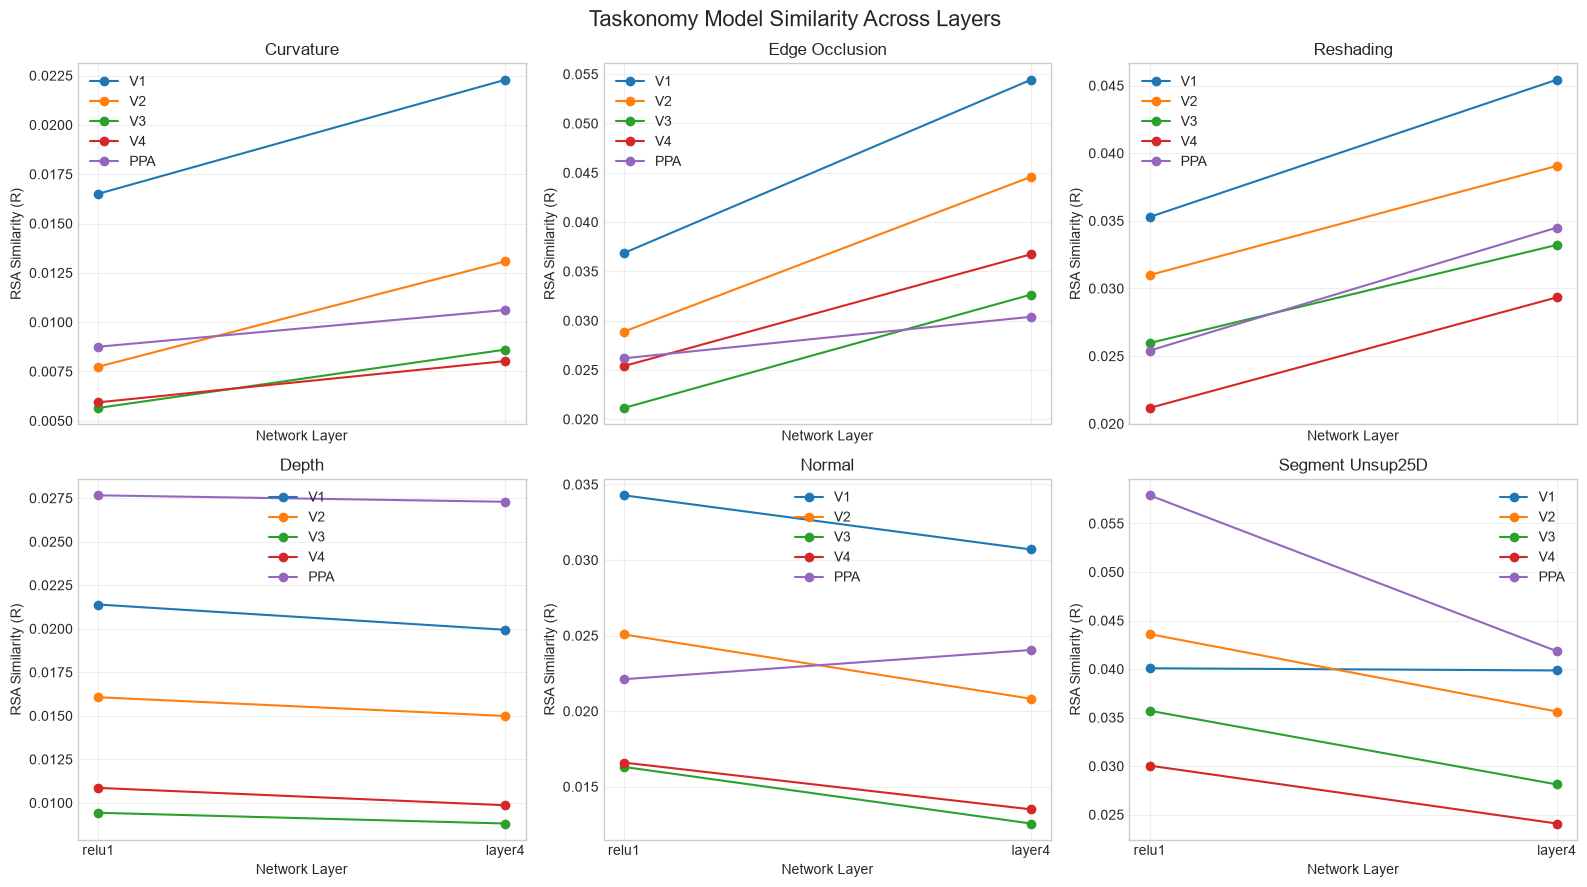

In [76]:
import matplotlib.pyplot as plt

models = [
    "Curvature",
    "Edge Occlusion",
    "Reshading",
    "Depth",
    "Normal",
    "Segment Unsup25D"
]

roi_order = ["V1", "V2", "V3", "V4", "PPA"]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
    sharex=True
)

axes = axes.flatten()

for ax, model_name in zip(axes, models):

    model_data = df_plot_summary[
        df_plot_summary["Model"] == model_name
    ]

    for roi_name in roi_order:

        roi_data = model_data[
            model_data["ROI_Group"] == roi_name
        ].sort_values("Layer_Number")

        ax.plot(
            roi_data["Layer_Number"],
            roi_data["R"],
            marker="o",
            label=roi_name
        )

    ax.set_title(model_name)

    ax.set_xlabel("Network Layer")
    ax.set_ylabel("RSA Similarity (R)")

    ax.set_xticks([1, 4])
    ax.set_xticklabels(["relu1", "layer4"])

    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(
    "Taskonomy Model Similarity Across Layers",
    fontsize=16
)

plt.tight_layout()
plt.show()

## VPA


### VPA for 4 RDM 

In [82]:
import os

models_3d = {
    "Curvature": [
        "curvature_RDMs_NSD_relu1_layer4/RDM_relu1.npz",
        "curvature_RDMs_NSD_relu1_layer4/RDM_layer4.npz"
    ],

    "Edge Occlusion": [
        "edge_occlusion_RDMs_NSD_relu1_layer4/RDM_relu1.npz",
        "edge_occlusion_RDMs_NSD_relu1_layer4/RDM_layer4.npz"
    ],

    "Reshading": [
        "reshading_RDMs_NSD_relu1_layer4/RDM_relu1.npz",
        "reshading_RDMs_NSD_relu1_layer4/RDM_layer4.npz"
    ],

    "Depth": [
        "depth_RDMs_NSD_relu1_layer4/RDM_relu1.npz",
        "depth_RDMs_NSD_relu1_layer4/RDM_layer4.npz"
    ]
}

independent_variables = list(models_3d.values())
variable_names = list(models_3d.keys())

print("VPA predictors:")

for name, paths in models_3d.items():
    print(f"\n{name}")
    for path in paths:
        print(" ", path, "→", os.path.exists(path))

VPA predictors:

Curvature
  curvature_RDMs_NSD_relu1_layer4/RDM_relu1.npz → True
  curvature_RDMs_NSD_relu1_layer4/RDM_layer4.npz → True

Edge Occlusion
  edge_occlusion_RDMs_NSD_relu1_layer4/RDM_relu1.npz → True
  edge_occlusion_RDMs_NSD_relu1_layer4/RDM_layer4.npz → True

Reshading
  reshading_RDMs_NSD_relu1_layer4/RDM_relu1.npz → True
  reshading_RDMs_NSD_relu1_layer4/RDM_layer4.npz → True

Depth
  depth_RDMs_NSD_relu1_layer4/RDM_relu1.npz → True
  depth_RDMs_NSD_relu1_layer4/RDM_layer4.npz → True


In [7]:
from pathlib import Path

nsd_path = Path("../Algonauts23_shared_Net2Brain")

brain_rois = {}

visual_rois = [
    "V1d",
    "V1v",
    "V2d",
    "V2v",
    "V3d",
    "V3v",
    "hV4"
]

for roi in visual_rois:
    for hemisphere in ["lh", "rh"]:

        roi_name = f"{roi}_{hemisphere}"

        brain_rois[roi_name] = [
            nsd_path
            / f"subj{subject_num:02d}"
            / "rdms"
            / f"{roi}_{hemisphere}_subj{subject_num:02d}.npy"
            for subject_num in range(1, 9)
        ]


# PPA
for hemisphere in ["lh", "rh"]:

    roi_name = f"PPA_{hemisphere}"

    brain_rois[roi_name] = [
        nsd_path
        / f"subj{subject_num:02d}"
        / "rdms"
        / f"PPA_{hemisphere}_subj{subject_num:02d}.npy"
        for subject_num in range(1, 9)
    ]


print("Number of ROIs:", len(brain_rois))

for roi_name, paths in brain_rois.items():

    print(
        roi_name,
        "→",
        len(paths),
        "subject files"
    )

    print(
        "   All exist:",
        all(path.exists() for path in paths)
    )

Number of ROIs: 16
V1d_lh → 8 subject files
   All exist: True
V1d_rh → 8 subject files
   All exist: True
V1v_lh → 8 subject files
   All exist: True
V1v_rh → 8 subject files
   All exist: True
V2d_lh → 8 subject files
   All exist: True
V2d_rh → 8 subject files
   All exist: True
V2v_lh → 8 subject files
   All exist: True
V2v_rh → 8 subject files
   All exist: True
V3d_lh → 8 subject files
   All exist: True
V3d_rh → 8 subject files
   All exist: True
V3v_lh → 8 subject files
   All exist: True
V3v_rh → 8 subject files
   All exist: True
hV4_lh → 8 subject files
   All exist: True
hV4_rh → 8 subject files
   All exist: True
PPA_lh → 8 subject files
   All exist: True
PPA_rh → 8 subject files
   All exist: True


In [84]:
import numpy as np
import os

vpa_brain_folder = "VPA_brain_data_NSD_relu"

os.makedirs(
    vpa_brain_folder,
    exist_ok=True
)

brain_vpa_paths = {}

for roi_name, subject_paths in brain_rois.items():

    print(
        "\nProcessing:",
        roi_name
    )

    subject_rdms = []

    for path in subject_paths:

        # Load condensed NSD RDM
        rdm = np.load(path)

        print(
            " ",
            path.name,
            "→",
            rdm.shape
        )

        subject_rdms.append(rdm)

    # Stack 8 subjects
    brain_data = np.stack(subject_rdms)

    print(
        " ",
        roi_name,
        "combined shape:",
        brain_data.shape
    )

    # Add singleton time dimension
    # (subjects, pairs)
    # →
    # (subjects, 1, pairs)

    brain_vpa = brain_data[
        :,
        np.newaxis,
        :
    ]

    print(
        " ",
        roi_name,
        "VPA shape:",
        brain_vpa.shape
    )

    save_path = os.path.join(
        vpa_brain_folder,
        f"{roi_name}_vpa.npy"
    )

    np.save(
        save_path,
        brain_vpa
    )

    brain_vpa_paths[roi_name] = save_path


print("\nSaved brain VPA files:")

for roi_name, path in brain_vpa_paths.items():

    print(
        roi_name,
        "→",
        path,
        "→",
        os.path.exists(path)
    )


Processing: V1d_lh
  V1d_lh_subj01.npy → (379756,)
  V1d_lh_subj02.npy → (379756,)
  V1d_lh_subj03.npy → (379756,)
  V1d_lh_subj04.npy → (379756,)
  V1d_lh_subj05.npy → (379756,)
  V1d_lh_subj06.npy → (379756,)
  V1d_lh_subj07.npy → (379756,)
  V1d_lh_subj08.npy → (379756,)
  V1d_lh combined shape: (8, 379756)
  V1d_lh VPA shape: (8, 1, 379756)

Processing: V1d_rh
  V1d_rh_subj01.npy → (379756,)
  V1d_rh_subj02.npy → (379756,)
  V1d_rh_subj03.npy → (379756,)
  V1d_rh_subj04.npy → (379756,)
  V1d_rh_subj05.npy → (379756,)
  V1d_rh_subj06.npy → (379756,)
  V1d_rh_subj07.npy → (379756,)
  V1d_rh_subj08.npy → (379756,)
  V1d_rh combined shape: (8, 379756)
  V1d_rh VPA shape: (8, 1, 379756)

Processing: V1v_lh
  V1v_lh_subj01.npy → (379756,)
  V1v_lh_subj02.npy → (379756,)
  V1v_lh_subj03.npy → (379756,)
  V1v_lh_subj04.npy → (379756,)
  V1v_lh_subj05.npy → (379756,)
  V1v_lh_subj06.npy → (379756,)
  V1v_lh_subj07.npy → (379756,)
  V1v_lh_subj08.npy → (379756,)
  V1v_lh combined shape: (8,

In [85]:
import pandas as pd

all_vpa_results = []

for roi_name, dependent_variable_vpa in brain_vpa_paths.items():

    print(
        "Running VPA for:",
        roi_name
    )

    VPA_eval = VPA(

        dependent_variable_vpa,

        independent_variables,

        variable_names

    )

    df_vpa = VPA_eval.evaluate(

        average_models=True

    )

    # Add ROI name to result

    df_vpa["ROI"] = roi_name


    all_vpa_results.append(
        df_vpa
    )


# Combine all ROIs

df_vpa_all = pd.concat(

    all_vpa_results,

    ignore_index=True

)

print(
    "Final shape:",
    df_vpa_all.shape
)

display(
    df_vpa_all.head()
)

Running VPA for: V1d_lh
Running VPA for: V1d_rh
Running VPA for: V1v_lh
Running VPA for: V1v_rh
Running VPA for: V2d_lh
Running VPA for: V2d_rh
Running VPA for: V2v_lh
Running VPA for: V2v_rh
Running VPA for: V3d_lh
Running VPA for: V3d_rh
Running VPA for: V3v_lh
Running VPA for: V3v_rh
Running VPA for: hV4_lh
Running VPA for: hV4_rh
Running VPA for: PPA_lh
Running VPA for: PPA_rh
Final shape: (448, 6)


,Variable,Description,Values,Significance,Color,ROI
0,R1,Curvature Influence,"[[0.00145844167637188], [0.0004173657793495877...",[0.007963319659433664],None,V1d_lh
1,R2,Edge Occlusion Influence,"[[0.0030375015719071863], [0.00105190081910522...",[0.0009156511665579096],None,V1d_lh
2,R3,Reshading Influence,"[[0.0026025170504442308], [0.00215113067959482...",[0.00011638331310015957],None,V1d_lh
3,R4,Depth Influence,"[[0.00014403655268480087], [0.0001757502937347...",[0.003082079148271734],None,V1d_lh
4,R12,Combined Curvature and Edge Occlusion Influence,"[[0.0034465115264581403], [0.00114637959684149...",[0.0013703249673001885],None,V1d_lh


In [86]:
df_vpa_filtered = df_vpa_all.query(
    "Variable in ['y1234', 'y1', 'y2', 'y3', 'y4']"
).reset_index(drop=True)

display(df_vpa_filtered)

,Variable,Description,Values,Significance,Color,ROI
0,y1,Unique Curvature,"[[0.0003228339492381549], [3.4852103226512554e...",[0.10161327983375304],None,V1d_lh
1,y2,Unique Edge Occlusion,"[[0.001144973601544641], [0.000203375399073224...",[0.002444818199368349],None,V1d_lh
2,y3,Unique Reshading,"[[0.0010571863463774145], [0.00133262958645974...",[0.00019006270621447867],None,V1d_lh
3,y4,Unique Depth,"[[7.144817553284e-05], [5.885971343655427e-07]...",[0.023440422861934294],None,V1d_lh
4,y1234,Shared Variance Curvature and Edge Occlusion a...,"[[0.00011756531983631024], [6.940606012262318e...",[0.0008633411180138021],None,V1d_lh
...,...,...,...,...,...,...
75,y1,Unique Curvature,"[[4.9360982079527105e-08], [4.3047202580304145...",[0.05268908384528723],None,PPA_rh
76,y2,Unique Edge Occlusion,"[[0.00039172648441543334], [0.0012447408769397...",[0.00886166557433321],None,PPA_rh
77,y3,Unique Reshading,"[[7.15253971754759e-05], [0.000283296615307571...",[0.002979824759073755],None,PPA_rh
78,y4,Unique Depth,"[[0.0013328996860834108], [0.00056765268759217...",[0.018000744198793113],None,PPA_rh


In [87]:
df_vpa_plot = df_vpa_filtered.copy()

df_vpa_plot["Significance"] = (
    df_vpa_plot["Significance"].apply(
        lambda x:
        float(np.asarray(x).squeeze())
    )
)

display(df_vpa_plot)

,Variable,Description,Values,Significance,Color,ROI
0,y1,Unique Curvature,"[[0.0003228339492381549], [3.4852103226512554e...",0.101613,None,V1d_lh
1,y2,Unique Edge Occlusion,"[[0.001144973601544641], [0.000203375399073224...",0.002445,None,V1d_lh
2,y3,Unique Reshading,"[[0.0010571863463774145], [0.00133262958645974...",0.000190,None,V1d_lh
3,y4,Unique Depth,"[[7.144817553284e-05], [5.885971343655427e-07]...",0.023440,None,V1d_lh
4,y1234,Shared Variance Curvature and Edge Occlusion a...,"[[0.00011756531983631024], [6.940606012262318e...",0.000863,None,V1d_lh
...,...,...,...,...,...,...
75,y1,Unique Curvature,"[[4.9360982079527105e-08], [4.3047202580304145...",0.052689,None,PPA_rh
76,y2,Unique Edge Occlusion,"[[0.00039172648441543334], [0.0012447408769397...",0.008862,None,PPA_rh
77,y3,Unique Reshading,"[[7.15253971754759e-05], [0.000283296615307571...",0.002980,None,PPA_rh
78,y4,Unique Depth,"[[0.0013328996860834108], [0.00056765268759217...",0.018001,None,PPA_rh


In [88]:
print("ROIs:")
print(df_vpa_plot["ROI"].unique())
print("\nVariables:")
print(df_vpa_plot["Variable"].unique())
print("\nNumber of results per ROI:")
print(df_vpa_plot.groupby("ROI").size())

ROIs:
['V1d_lh' 'V1d_rh' 'V1v_lh' 'V1v_rh' 'V2d_lh' 'V2d_rh' 'V2v_lh' 'V2v_rh'
 'V3d_lh' 'V3d_rh' 'V3v_lh' 'V3v_rh' 'hV4_lh' 'hV4_rh' 'PPA_lh' 'PPA_rh']

Variables:
['y1' 'y2' 'y3' 'y4' 'y1234']

Number of results per ROI:
ROI
PPA_lh    5
PPA_rh    5
V1d_lh    5
V1d_rh    5
V1v_lh    5
V1v_rh    5
V2d_lh    5
V2d_rh    5
V2v_lh    5
V2v_rh    5
V3d_lh    5
V3d_rh    5
V3v_lh    5
V3v_rh    5
hV4_lh    5
hV4_rh    5
dtype: int64


V1d_lh


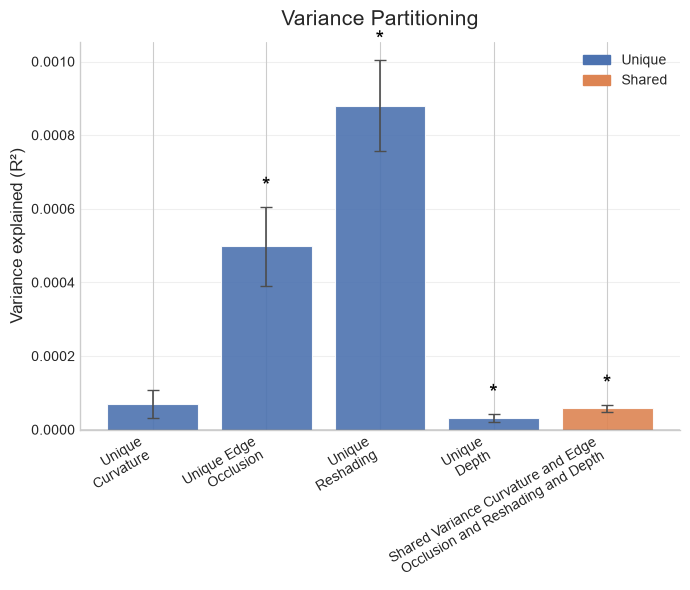

V2d_lh


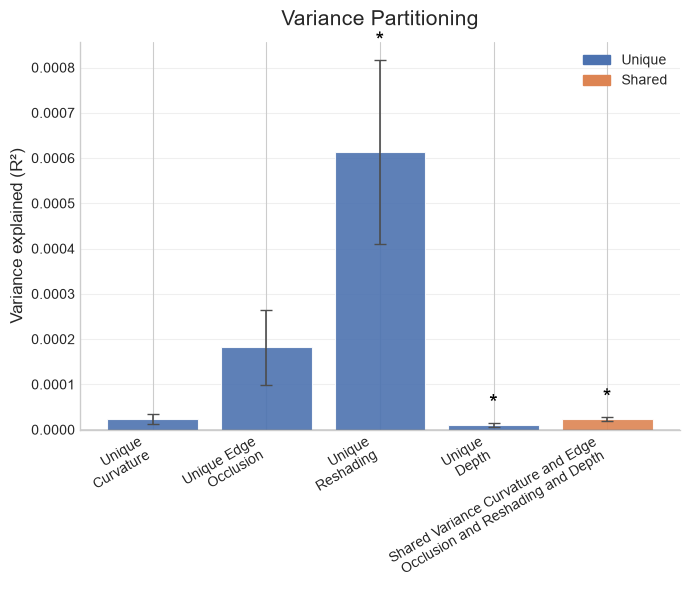

V3d_lh


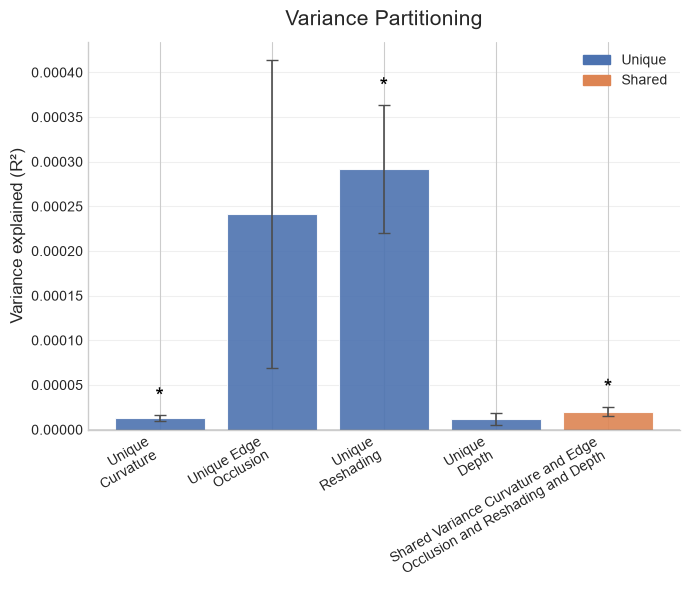

hV4_lh


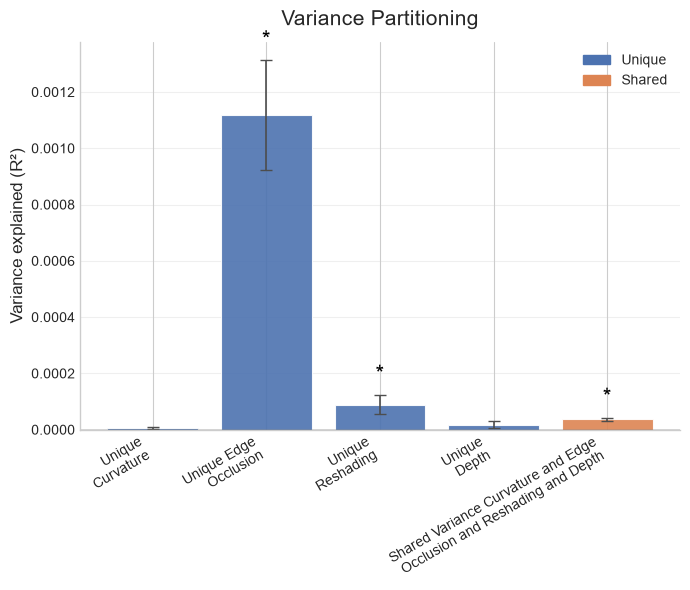

PPA_lh


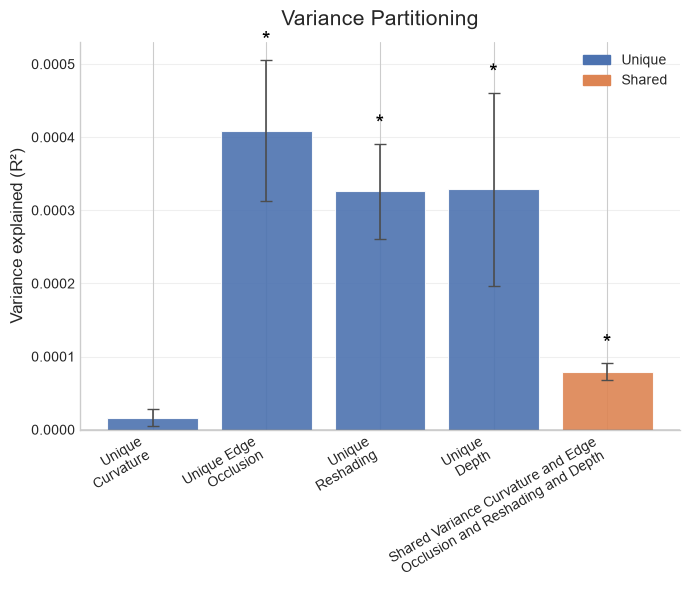

In [89]:
from net2brain.evaluations.plotting import Plotting

# df_ppa_vpa = df_vpa_plot[df_vpa_plot["ROI"] == "PPA"].copy()

for roi in [
    "V1d_lh",
    "V2d_lh",
    "V3d_lh",
    "hV4_lh",
    "PPA_lh"
]:

    print(roi)

    df_roi = df_vpa_plot[
        df_vpa_plot["ROI"] == roi
    ]

    plotter = Plotting(df_roi)
    plotter.plotting_components()

In [92]:
import numpy as np

df_plot = df_vpa_plot.copy()

# Mean across subjects
df_plot["Mean"] = df_plot["Values"].apply(
    lambda x: np.mean(np.asarray(x, dtype=float))
)

# SEM across subjects
df_plot["SEM"] = df_plot["Values"].apply(
    lambda x: (
        np.std(np.asarray(x, dtype=float), ddof=1)
        / np.sqrt(len(np.asarray(x, dtype=float)))
    )
)

print(df_plot.columns.tolist())
display(df_plot.head())

['Variable', 'Description', 'Values', 'Significance', 'Color', 'ROI', 'Mean', 'SEM']


,Variable,Description,Values,Significance,Color,ROI,Mean,SEM
0,y1,Unique Curvature,"[[0.0003228339492381549], [3.4852103226512554e...",0.101613,None,V1d_lh,0.000069,0.000037
1,y2,Unique Edge Occlusion,"[[0.001144973601544641], [0.000203375399073224...",0.002445,None,V1d_lh,0.000498,0.000108
2,y3,Unique Reshading,"[[0.0010571863463774145], [0.00133262958645974...",0.000190,None,V1d_lh,0.000880,0.000124
3,y4,Unique Depth,"[[7.144817553284e-05], [5.885971343655427e-07]...",0.023440,None,V1d_lh,0.000032,0.000011
4,y1234,Shared Variance Curvature and Edge Occlusion a...,"[[0.00011756531983631024], [6.940606012262318e...",0.000863,None,V1d_lh,0.000058,0.000010


In [93]:
import pandas as pd

pivot = df_plot.pivot(
    index="ROI",
    columns="Variable",
    values="Mean"
)

display(pivot.head())

Variable,y1,y1234,y2,y3,y4
ROI,,,,,
PPA_lh,0.000016,0.000079,0.000409,0.000326,0.000329
PPA_rh,0.000011,0.000093,0.000431,0.000373,0.000433
V1d_lh,0.000069,0.000058,0.000498,0.000880,0.000032
V1d_rh,0.000091,0.000054,0.000649,0.000669,0.000047
V1v_lh,0.000179,0.000230,0.004812,0.000074,0.000241


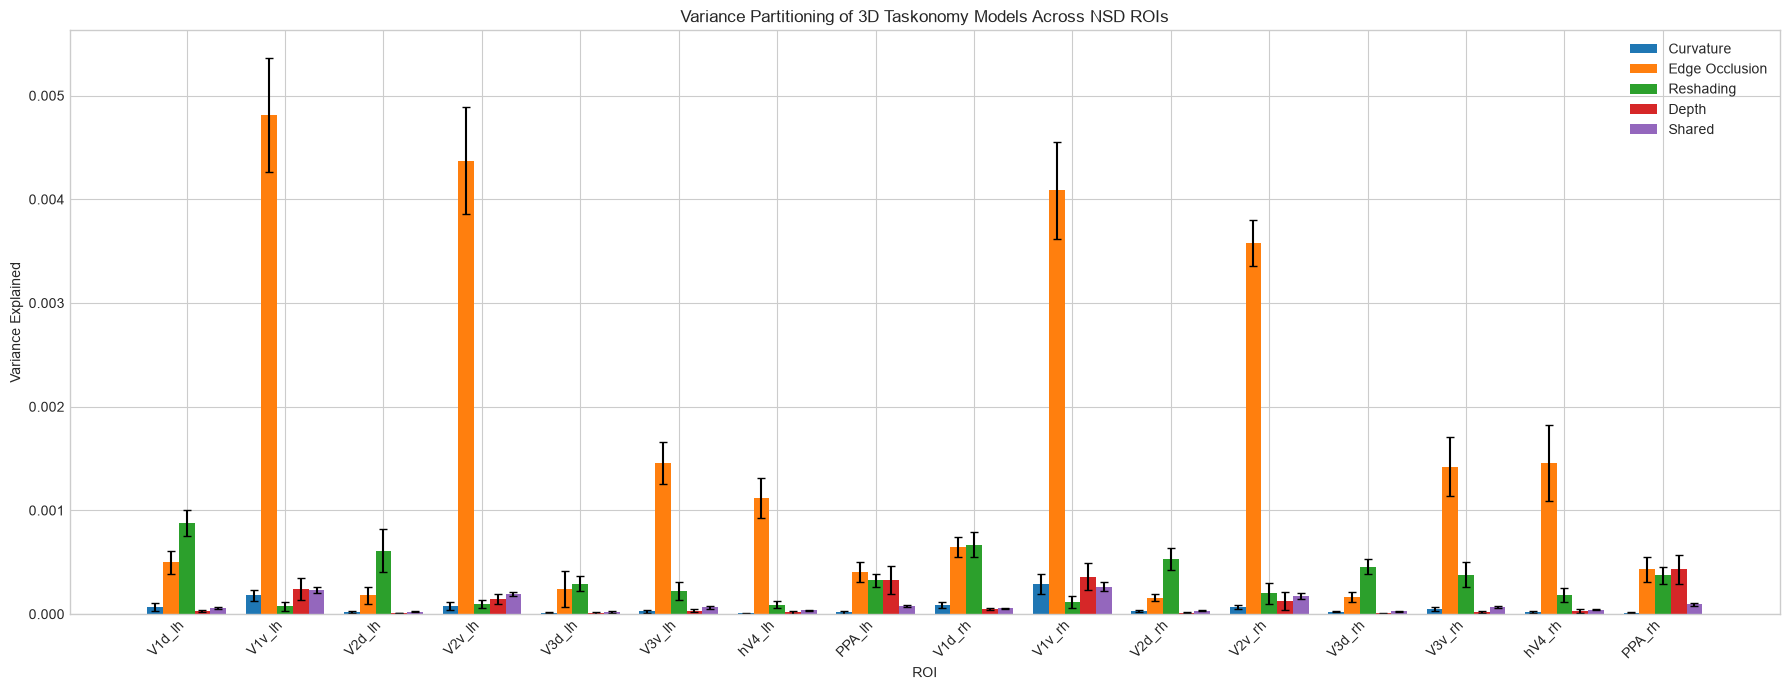

In [94]:
import matplotlib.pyplot as plt
import numpy as np

name_map = {
    "y1": "Curvature",
    "y2": "Edge Occlusion",
    "y3": "Reshading",
    "y4": "Depth",
    "y1234": "Shared"
}

df_plot["Component"] = df_plot["Variable"].map(name_map)

# Fixed ROI order for NSD
roi_order = [
    "V1d_lh",
    "V1v_lh",
    "V2d_lh",
    "V2v_lh",
    "V3d_lh",
    "V3v_lh",
    "hV4_lh",
    "PPA_lh",
    "V1d_rh",
    "V1v_rh",
    "V2d_rh",
    "V2v_rh",
    "V3d_rh",
    "V3v_rh",
    "hV4_rh",
    "PPA_rh"
]

# Keep only ROIs that actually exist
rois = [
    roi for roi in roi_order
    if roi in df_plot["ROI"].unique()
]

components = [
    "Curvature",
    "Edge Occlusion",
    "Reshading",
    "Depth",
    "Shared"
]

x = np.arange(len(rois))
width = 0.16

fig, ax = plt.subplots(figsize=(18, 7))

for i, comp in enumerate(components):

    subset = df_plot[
        df_plot["Component"] == comp
    ]

    means = []
    sems = []

    for roi in rois:

        row = subset[
            subset["ROI"] == roi
        ]

        if not row.empty:
            means.append(row.iloc[0]["Mean"])
            sems.append(row.iloc[0]["SEM"])
        else:
            means.append(np.nan)
            sems.append(0)

    ax.bar(
        x + (i - 2) * width,
        means,
        width,
        label=comp,
        yerr=sems,
        capsize=3
    )

ax.set_xticks(x)
ax.set_xticklabels(
    rois,
    rotation=45,
    ha="right"
)

ax.set_ylabel("Variance Explained")
ax.set_xlabel("ROI")
ax.set_title(
    "Variance Partitioning of 3D Taskonomy Models Across NSD ROIs"
)

ax.legend()

plt.tight_layout()
plt.show()

## Combine Average 3D

In [95]:
import numpy as np
from pathlib import Path

# 3D TASKONOMY RDM COMBINATION
models_3d = {
    "Curvature": Path("curvature_RDMs_NSD_relu1_layer4"),
    "Edge_Occlusion": Path("edge_occlusion_RDMs_NSD_relu1_layer4"),
    "Reshading": Path("reshading_RDMs_NSD_relu1_layer4"),
    "Depth": Path("depth_RDMs_NSD_relu1_layer4"),
    "Normal": Path("normal_RDMs_NSD_relu1_layer4"),
    "Segment_Unsup25D": Path("segment_unsup25d_RDMs_NSD_relu1_layer4"),
}

# Last two encoder layers
layers = [
    "RDM_relu1.npz",
    "RDM_layer4.npz"
]

output_file = Path("3D_RDM_NSD.npz")

# LOAD RDM
def load_rdm(path):

    data = np.load(path, allow_pickle=True)

    print(f"\nLoading: {path}")
    print("Keys:", data.files)

    if "rdm" not in data.files:
        raise KeyError(
            f"'rdm' not found in {path}. "
            f"Available keys: {data.files}"
        )

    rdm = np.asarray(
        data["rdm"],
        dtype=float
    )

    print("Shape:", rdm.shape)

    return rdm

# Z-SCORE
def zscore_rdm(rdm):

    std = np.std(rdm)

    if std == 0:
        raise ValueError(
            "RDM has zero standard deviation."
        )

    return (
        (rdm - np.mean(rdm))
        / std
    )

# LOAD ALL 12 RDMs
rdms = []
stimuli_reference = None

for model_name, model_path in models_3d.items():

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    if not model_path.exists():
        raise FileNotFoundError(
            f"Folder not found: {model_path.resolve()}"
        )

    for layer_file in layers:

        rdm_path = model_path / layer_file

        if not rdm_path.exists():
            raise FileNotFoundError(
                f"RDM file not found: {rdm_path.resolve()}"
            )

        data = np.load(
            rdm_path,
            allow_pickle=True
        )

        rdm = np.asarray(
            data["rdm"],
            dtype=float
        )

        print(
            f"{model_name} | {layer_file} | "
            f"shape = {rdm.shape}"
        )

        # Check stimulus order
        if "stimuli_name" in data.files:

            stimuli = data["stimuli_name"]

            if stimuli_reference is None:

                stimuli_reference = stimuli

            elif not np.array_equal(
                stimuli_reference,
                stimuli
            ):

                raise ValueError(
                    f"Stimulus ordering differs in "
                    f"{rdm_path}"
                )

        # Z-score before combining
        rdm = zscore_rdm(rdm)

        rdms.append(rdm)

# CHECK SHAPES
print("\n" + "=" * 60)
print("CHECKING RDM SHAPES")
print("=" * 60)

shapes = [
    rdm.shape
    for rdm in rdms
]

for i, shape in enumerate(shapes, 1):
    print(f"RDM {i}: {shape}")

if len(set(shapes)) != 1:

    raise ValueError(
        f"RDM shapes are not identical: {shapes}"
    )

print(
    "\nAll 12 RDMs have the same shape:",
    shapes[0]
)

# COMBINE
rdms_stack = np.stack(
    rdms,
    axis=0
)

print(
    "\nStacked RDM shape:",
    rdms_stack.shape
)

rdm_3d = np.mean(
    rdms_stack,
    axis=0
)

print(
    "Combined 3D RDM shape:",
    rdm_3d.shape
)

# SAVE
save_kwargs = {
    "rdm": rdm_3d,
    "models": np.array(
        list(models_3d.keys())
    ),
    "layers": np.array(
        ["relu1", "layer4"]
    )
}

if stimuli_reference is not None:
    save_kwargs["stimuli_name"] = stimuli_reference

np.savez(
    output_file,
    **save_kwargs
)

print("\nSaved combined 3D RDM to:")
print(output_file.resolve())

print("\n" + "=" * 60)
print("VERIFICATION")
print("=" * 60)

print("Minimum:", np.min(rdm_3d))
print("Maximum:", np.max(rdm_3d))
print("Mean:", np.mean(rdm_3d))
print("Std:", np.std(rdm_3d))
print("NaN:", np.isnan(rdm_3d).any())
print("Inf:", np.isinf(rdm_3d).any())


Curvature
Curvature | RDM_relu1.npz | shape = (379756,)
Curvature | RDM_layer4.npz | shape = (379756,)

Edge_Occlusion
Edge_Occlusion | RDM_relu1.npz | shape = (379756,)
Edge_Occlusion | RDM_layer4.npz | shape = (379756,)

Reshading
Reshading | RDM_relu1.npz | shape = (379756,)
Reshading | RDM_layer4.npz | shape = (379756,)

Depth
Depth | RDM_relu1.npz | shape = (379756,)
Depth | RDM_layer4.npz | shape = (379756,)

Normal
Normal | RDM_relu1.npz | shape = (379756,)
Normal | RDM_layer4.npz | shape = (379756,)

Segment_Unsup25D
Segment_Unsup25D | RDM_relu1.npz | shape = (379756,)
Segment_Unsup25D | RDM_layer4.npz | shape = (379756,)

CHECKING RDM SHAPES
RDM 1: (379756,)
RDM 2: (379756,)
RDM 3: (379756,)
RDM 4: (379756,)
RDM 5: (379756,)
RDM 6: (379756,)
RDM 7: (379756,)
RDM 8: (379756,)
RDM 9: (379756,)
RDM 10: (379756,)
RDM 11: (379756,)
RDM 12: (379756,)

All 12 RDMs have the same shape: (379756,)

Stacked RDM shape: (12, 379756)
Combined 3D RDM shape: (379756,)

Saved combined 3D RDM 

In [96]:
import numpy as np
from pathlib import Path

models_3d = {
    "Curvature": Path("curvature_RDMs_NSD_relu1_layer4"),
    "Edge_Occlusion": Path("edge_occlusion_RDMs_NSD_relu1_layer4"),
    "Reshading": Path("reshading_RDMs_NSD_relu1_layer4"),
    "Depth": Path("depth_RDMs_NSD_relu1_layer4"),
    "Normal": Path("normal_RDMs_NSD_relu1_layer4"),
    "Segment_Unsup25D": Path("segment_unsup25d_RDMs_NSD_relu1_layer4")
}

layers = [
    "RDM_relu1.npz",
    "RDM_layer4.npz"
]

reference = None

for model_name, folder in models_3d.items():

    for layer in layers:

        path = folder / layer

        data = np.load(
            path,
            allow_pickle=True
        )

        if "stimuli_name" not in data.files:
            print(
                f"{model_name} {layer}: "
                "no stimuli_name stored"
            )
            continue

        stimuli = data["stimuli_name"]

        if reference is None:

            reference = stimuli

            print(
                f"Reference: "
                f"{model_name} {layer}"
            )

        else:

            same = np.array_equal(
                reference,
                stimuli
            )

            print(
                f"{model_name} {layer}: "
                f"same stimulus order = {same}"
            )

            if not same:
                raise ValueError(
                    f"Stimulus order differs: "
                    f"{model_name} {layer}"
                )

Reference: Curvature RDM_relu1.npz
Curvature RDM_layer4.npz: same stimulus order = True
Edge_Occlusion RDM_relu1.npz: same stimulus order = True
Edge_Occlusion RDM_layer4.npz: same stimulus order = True
Reshading RDM_relu1.npz: same stimulus order = True
Reshading RDM_layer4.npz: same stimulus order = True
Depth RDM_relu1.npz: same stimulus order = True
Depth RDM_layer4.npz: same stimulus order = True
Normal RDM_relu1.npz: same stimulus order = True
Normal RDM_layer4.npz: same stimulus order = True
Segment_Unsup25D RDM_relu1.npz: same stimulus order = True
Segment_Unsup25D RDM_layer4.npz: same stimulus order = True


## VPA (2D,3D, Sem)

In [8]:
import numpy as np

for path in [
    "2D_RDM_NSD.npz",
    "3D_RDM_NSD.npz",
    "Semantic_RDM_NSD.npz"
]:
    d = np.load(path, allow_pickle=True)

    print("\n", path)
    print("keys:", d.files)
    print("shape:", d["rdm"].shape)

    if "stimuli_name" in d.files:
        print("\nstimuli:", len(d["stimuli_name"]))


 2D_RDM_NSD.npz
keys: ['rdm', 'models', 'layers', 'stimuli_name']
shape: (379756,)

stimuli: 872

 3D_RDM_NSD.npz
keys: ['rdm', 'models', 'layers', 'stimuli_name']
shape: (379756,)

stimuli: 872

 Semantic_RDM_NSD.npz
keys: ['rdm', 'models', 'layers', 'stimuli_name']
shape: (379756,)

stimuli: 872


In [9]:
import numpy as np
from pathlib import Path

visual_rdm_folder = Path("NSD_visual_RDMs")
ppa_rdm_folder = Path("NSD_PPA_RDMs")

vpa_brain_folder = Path("VPA_brain_data_NSD")
vpa_brain_folder.mkdir(exist_ok=True)

brain_rois = {}

visual_rois = [
    "hV4_lh",
    "hV4_rh",
    "V1d_lh",
    "V1d_rh",
    "V1v_lh",
    "V1v_rh",
    "V2d_lh",
    "V2d_rh",
    "V2v_lh",
    "V2v_rh",
    "V3d_lh",
    "V3d_rh",
    "V3v_lh",
    "V3v_rh",
]

# Existing visual ROIs
for roi in visual_rois:
    brain_rois[roi] = visual_rdm_folder / f"{roi}.npz"

# PPA
brain_rois["PPA_lh"] = ppa_rdm_folder / "PPA_lh.npz"
brain_rois["PPA_rh"] = ppa_rdm_folder / "PPA_rh.npz"


# --------------------------------------------------
# OPA: build 8-subject RDMs from the original NSD data
# --------------------------------------------------

for hemisphere in ["lh", "rh"]:

    opa_subject_rdms = []

    for subject_number in range(1, 9):

        subject = f"subj{subject_number:02d}"

        opa_file = (
            nsd_path
            / subject
            / "rdms"
            / f"OPA_{hemisphere}_{subject}.npy"
        )

        if not opa_file.exists():
            raise FileNotFoundError(
                f"OPA file not found: {opa_file}"
            )

        opa_rdm = np.load(
            opa_file,
            allow_pickle=True
        )

        print(
            f"Loaded {subject} OPA_{hemisphere}:",
            opa_rdm.shape
        )

        assert opa_rdm.shape == (379756,), (
            f"Unexpected OPA shape: {opa_rdm.shape}"
        )

        opa_subject_rdms.append(opa_rdm)

    # Convert to (8, 379756)
    opa_subject_rdms = np.stack(
        opa_subject_rdms,
        axis=0
    )

    # Convert each subject from condensed → square
    opa_square = np.zeros(
        (8, 872, 872),
        dtype=float
    )

    from scipy.spatial.distance import squareform

    for subject_index in range(8):

        opa_square[subject_index] = squareform(
            opa_subject_rdms[subject_index],
            checks=False
        )

    # Save in same format as your existing visual RDMs
    output_path = (
        visual_rdm_folder
        / f"OPA_{hemisphere}.npz"
    )

    np.savez(
        output_path,
        rdm=opa_square
    )

    brain_rois[
        f"OPA_{hemisphere}"
    ] = output_path

    print(
        f"Saved OPA_{hemisphere}:",
        output_path
    )


# --------------------------------------------------
# Convert every ROI to VPA format
# --------------------------------------------------

brain_vpa_paths = {}

triu_idx = np.triu_indices(
    872,
    k=1
)

for roi_name, brain_path in brain_rois.items():

    print("\nProcessing:", roi_name)

    brain_data = np.load(
        brain_path,
        allow_pickle=True
    )["rdm"]

    print(
        "Original shape:",
        brain_data.shape
    )

    assert brain_data.shape == (
        8,
        872,
        872
    ), (
        f"Unexpected shape for {roi_name}: "
        f"{brain_data.shape}"
    )

    brain_vectorized = brain_data[
        :,
        triu_idx[0],
        triu_idx[1]
    ]

    print(
        "Vectorized shape:",
        brain_vectorized.shape
    )

    brain_vpa = brain_vectorized[
        :,
        np.newaxis,
        :
    ]

    print(
        "VPA shape:",
        brain_vpa.shape
    )

    output_path = (
        vpa_brain_folder
        / f"{roi_name}_vpa.npy"
    )

    np.save(
        output_path,
        brain_vpa
    )

    brain_vpa_paths[
        roi_name
    ] = str(output_path)

    print(
        "Saved:",
        output_path
    )

print("\nFinished.")
print(
    "Number of ROIs:",
    len(brain_vpa_paths)
)
print(
    "ROIs:",
    list(brain_vpa_paths.keys())
)

Loaded subj01 OPA_lh: (379756,)
Loaded subj02 OPA_lh: (379756,)
Loaded subj03 OPA_lh: (379756,)
Loaded subj04 OPA_lh: (379756,)
Loaded subj05 OPA_lh: (379756,)
Loaded subj06 OPA_lh: (379756,)
Loaded subj07 OPA_lh: (379756,)
Loaded subj08 OPA_lh: (379756,)
Saved OPA_lh: NSD_visual_RDMs\OPA_lh.npz
Loaded subj01 OPA_rh: (379756,)
Loaded subj02 OPA_rh: (379756,)
Loaded subj03 OPA_rh: (379756,)
Loaded subj04 OPA_rh: (379756,)
Loaded subj05 OPA_rh: (379756,)
Loaded subj06 OPA_rh: (379756,)
Loaded subj07 OPA_rh: (379756,)
Loaded subj08 OPA_rh: (379756,)
Saved OPA_rh: NSD_visual_RDMs\OPA_rh.npz

Processing: hV4_lh
Original shape: (8, 872, 872)
Vectorized shape: (8, 379756)
VPA shape: (8, 1, 379756)
Saved: VPA_brain_data_NSD\hV4_lh_vpa.npy

Processing: hV4_rh
Original shape: (8, 872, 872)
Vectorized shape: (8, 379756)
VPA shape: (8, 1, 379756)
Saved: VPA_brain_data_NSD\hV4_rh_vpa.npy

Processing: V1d_lh
Original shape: (8, 872, 872)
Vectorized shape: (8, 379756)
VPA shape: (8, 1, 379756)
Saved:

In [10]:
from net2brain.evaluations.variance_partitioning_analysis import VPA
import pandas as pd

independent_variables = [
    "2D_RDM_NSD.npz",
    "3D_RDM_NSD.npz",
    "Semantic_RDM_NSD.npz"
]

variable_names = [
    "2D",
    "3D",
    "Semantic"
]

all_vpa_results = []

for roi_name, dependent_variable_vpa in brain_vpa_paths.items():

    print("Running:", roi_name)

    VPA_eval = VPA(
        dependent_variable_vpa,
        independent_variables,
        variable_names
    )

    df_vpa = VPA_eval.evaluate(
        average_models=True
    )

    df_vpa["ROI"] = roi_name

    all_vpa_results.append(df_vpa)

df_vpa_all = pd.concat(
    all_vpa_results,
    ignore_index=True
)

print(df_vpa_all.shape)

display(df_vpa_all.head(20))

Running: hV4_lh
Running: hV4_rh
Running: V1d_lh
Running: V1d_rh
Running: V1v_lh
Running: V1v_rh
Running: V2d_lh
Running: V2d_rh
Running: V2v_lh
Running: V2v_rh
Running: V3d_lh
Running: V3d_rh
Running: V3v_lh
Running: V3v_rh
Running: PPA_lh
Running: PPA_rh
Running: OPA_lh
Running: OPA_rh
(288, 6)


,Variable,Description,Values,Significance,Color,ROI
0,R1,2D Influence,"[[0.003770094370707411], [0.002617596776296804...",[0.0006610900612203454],None,hV4_lh
1,R2,3D Influence,"[[0.001999944218713523], [0.001249850260489959...",[0.00021525579338722506],None,hV4_lh
2,R3,Semantic Influence,"[[0.004118042149623857], [0.002465612931049299...",[8.704923243136728e-05],None,hV4_lh
3,R12,Combined 2D and 3D Influence,"[[0.003946063538190714], [0.002694515902839311...",[0.00045037451615287936],None,hV4_lh
4,R13,Combined 2D and Semantic Influence,"[[0.0061536775334279925], [0.00396468282819262...",[9.85037340436406e-05],None,hV4_lh
5,R23,Combined 3D and Semantic Influence,"[[0.004287314758030014], [0.002585451447378761...",[8.500286898699905e-05],None,hV4_lh
6,R123,Combined All Variables Influence,"[[0.006261470918880296], [0.004048575362436746...",[9.165012082669895e-05],None,hV4_lh
7,y123,Shared Variance All,"[[0.001762495828276367], [0.001136985151862113...",[0.0001543947667507579],None,hV4_lh
8,y12,Shared Variance 2D and 3D,"[[6.1479222953853e-05], [3.594598208533917e-05...",[0.9462269798036931],None,hV4_lh
9,y13,Shared Variance 2D and Semantic,"[[-2.803684137309137e-05], [-1.845827270863242...",[0.00013092960701102443],None,hV4_lh


In [11]:
for roi_name, path in brain_vpa_paths.items():
    data = np.load(path)

    print(roi_name)
    print("Path:", path)
    print("Shape:", data.shape)
    print()

hV4_lh
Path: VPA_brain_data_NSD\hV4_lh_vpa.npy
Shape: (8, 1, 379756)

hV4_rh
Path: VPA_brain_data_NSD\hV4_rh_vpa.npy
Shape: (8, 1, 379756)

V1d_lh
Path: VPA_brain_data_NSD\V1d_lh_vpa.npy
Shape: (8, 1, 379756)

V1d_rh
Path: VPA_brain_data_NSD\V1d_rh_vpa.npy
Shape: (8, 1, 379756)

V1v_lh
Path: VPA_brain_data_NSD\V1v_lh_vpa.npy
Shape: (8, 1, 379756)

V1v_rh
Path: VPA_brain_data_NSD\V1v_rh_vpa.npy
Shape: (8, 1, 379756)

V2d_lh
Path: VPA_brain_data_NSD\V2d_lh_vpa.npy
Shape: (8, 1, 379756)

V2d_rh
Path: VPA_brain_data_NSD\V2d_rh_vpa.npy
Shape: (8, 1, 379756)

V2v_lh
Path: VPA_brain_data_NSD\V2v_lh_vpa.npy
Shape: (8, 1, 379756)

V2v_rh
Path: VPA_brain_data_NSD\V2v_rh_vpa.npy
Shape: (8, 1, 379756)

V3d_lh
Path: VPA_brain_data_NSD\V3d_lh_vpa.npy
Shape: (8, 1, 379756)

V3d_rh
Path: VPA_brain_data_NSD\V3d_rh_vpa.npy
Shape: (8, 1, 379756)

V3v_lh
Path: VPA_brain_data_NSD\V3v_lh_vpa.npy
Shape: (8, 1, 379756)

V3v_rh
Path: VPA_brain_data_NSD\V3v_rh_vpa.npy
Shape: (8, 1, 379756)

PPA_lh
Path: VPA_bra

In [12]:
import numpy as np
import pandas as pd

df_plot = df_vpa_all.query(
    "Variable in ['y1', 'y2', 'y3', 'y123']"
).copy()

df_plot["Mean"] = df_plot["Values"].apply(
    lambda x: float(np.mean(np.asarray(x)))
)

df_plot["SEM"] = df_plot["Values"].apply(
    lambda x:
    np.std(np.asarray(x), ddof=1)
    / np.sqrt(len(np.asarray(x)))
)

name_map = {
    "y1": "Unique_2D",
    "y2": "Unique_3D",
    "y3": "Unique_Semantic",
    "y123": "Shared"
}

df_plot["Component"] = df_plot["Variable"].map(name_map)

display(df_plot.head())

,Variable,Description,Values,Significance,Color,ROI,Mean,SEM,Component
7,y123,Shared Variance All,"[[0.001762495828276367], [0.001136985151862113...",[0.0001543947667507579],None,hV4_lh,0.001092,0.000148,Shared
11,y1,Unique 2D,"[[0.0019741561608502822], [0.00146312391505798...",[0.001962402952907697],None,hV4_lh,0.000973,0.000203,Unique_2D
12,y2,Unique 3D,"[[0.00010779338545230388], [8.389253424412324e...",[0.00036975495323297825],None,hV4_lh,0.000072,0.000011,Unique_3D
13,y3,Unique Semantic,"[[0.0023154073806895825], [0.00135405945959743...",[0.00010803320937735756],None,hV4_lh,0.001905,0.000245,Unique_Semantic
23,y123,Shared Variance All,"[[0.002646817346881658], [0.001557371334457657...",[0.002083473614554233],None,hV4_rh,0.001178,0.000248,Shared


In [13]:
# Summary with LNC-normalized variance explained

summary = df_plot.pivot(
    index="ROI",
    columns="Component",
    values="Mean"
)

# --------------------------------------------------
# Raw total variance explained
# --------------------------------------------------

summary["R2_full"] = (
    summary["Unique_2D"]
    + summary["Unique_3D"]
    + summary["Unique_Semantic"]
    + summary["Shared"]
)

# --------------------------------------------------
# Extract LNC from VPA results
# --------------------------------------------------

lnc_data = (
    df_vpa_all[
        df_vpa_all["Variable"] == "LNC"
    ][["ROI", "Values"]]
    .copy()
)

lnc_data["LNC"] = lnc_data["Values"].apply(
    lambda x: float(
        np.asarray(x).flatten()[0]
    )
)

lnc_data = lnc_data[
    ["ROI", "LNC"]
].drop_duplicates(
    subset="ROI"
)

summary = summary.reset_index()

summary = summary.merge(
    lnc_data,
    on="ROI",
    how="left"
)

# --------------------------------------------------
# Divide EACH variance component by LNC
# --------------------------------------------------

summary["Unique_2D_LNC"] = (
    summary["Unique_2D"]
    / summary["LNC"]
)

summary["Unique_3D_LNC"] = (
    summary["Unique_3D"]
    / summary["LNC"]
)

summary["Unique_Semantic_LNC"] = (
    summary["Unique_Semantic"]
    / summary["LNC"]
)

summary["Shared_LNC"] = (
    summary["Shared"]
    / summary["LNC"]
)

# Total variance explained / LNC
summary["LNC_normalized_R2"] = (
    summary["R2_full"]
    / summary["LNC"]
)

summary = summary.set_index("ROI")

display(
    summary[[
        "R2_full",
        "LNC",
        "LNC_normalized_R2",
        "Unique_2D_LNC",
        "Unique_3D_LNC",
        "Unique_Semantic_LNC",
        "Shared_LNC"
    ]]
)

summary.to_csv(
    "UVP_summary_ROIs_NSD_LNC_normalized.csv"
)

,R2_full,LNC,LNC_normalized_R2,Unique_2D_LNC,Unique_3D_LNC,Unique_Semantic_LNC,Shared_LNC
ROI,,,,,,,
OPA_lh,0.005382,0.138226,0.038934,0.002453,0.000342,0.028451,0.007689
OPA_rh,0.005217,0.159304,0.032749,0.001879,0.000113,0.023715,0.007042
PPA_lh,0.006711,0.169846,0.039512,0.000560,0.000098,0.033274,0.005580
PPA_rh,0.007328,0.191527,0.038263,0.000284,0.000011,0.033193,0.004775
V1d_lh,0.009104,0.176120,0.051695,0.024613,0.002346,0.012510,0.012226
V1d_rh,0.008390,0.170802,0.049124,0.024181,0.001894,0.010938,0.012110
V1v_lh,0.012840,0.184608,0.069554,0.034836,0.000227,0.012783,0.021707
V1v_rh,0.011044,0.177215,0.062318,0.034662,0.000824,0.006868,0.019964
V2d_lh,0.003808,0.106242,0.035843,0.014307,0.001279,0.011050,0.009206


In [14]:
# Add LNC-normalized SEM

# --------------------------------------------------
# Extract LNC for each ROI
# --------------------------------------------------

lnc_lookup = (
    lnc_data
    .set_index("ROI")["LNC"]
    .to_dict()
)

# --------------------------------------------------
# Normalize each subject-level value by that ROI's LNC
# --------------------------------------------------

df_plot["Values_LNC"] = df_plot.apply(
    lambda row: (
        np.asarray(row["Values"], dtype=float).flatten()
        / lnc_lookup[row["ROI"]]
    ),
    axis=1
)

# --------------------------------------------------
# Calculate SEM after LNC normalization
# --------------------------------------------------

df_plot["SEM_LNC"] = df_plot["Values_LNC"].apply(
    lambda x:
        np.std(x, ddof=1)
        / np.sqrt(len(x))
)

# --------------------------------------------------
# Put normalized SEM into the summary
# --------------------------------------------------

sem_lnc_summary = df_plot.pivot(
    index="ROI",
    columns="Component",
    values="SEM_LNC"
)

summary = summary.join(
    sem_lnc_summary,
    rsuffix="_SEM"
)

display(summary)

,Shared,Unique_2D,Unique_3D,Unique_Semantic,R2_full,LNC,Unique_2D_LNC,Unique_3D_LNC,Unique_Semantic_LNC,Shared_LNC,LNC_normalized_R2,Shared_SEM,Unique_2D_SEM,Unique_3D_SEM,Unique_Semantic_SEM
ROI,,,,,,,,,,,,,,,
OPA_lh,0.001063,0.000339,0.000047,0.003933,0.005382,0.138226,0.002453,0.000342,0.028451,0.007689,0.038934,0.001784,0.000866,0.000159,0.005445
OPA_rh,0.001122,0.000299,0.000018,0.003778,0.005217,0.159304,0.001879,0.000113,0.023715,0.007042,0.032749,0.001548,0.000708,0.000073,0.003499
PPA_lh,0.000948,0.000095,0.000017,0.005651,0.006711,0.169846,0.000560,0.000098,0.033274,0.005580,0.039512,0.000932,0.000228,0.000032,0.004909
PPA_rh,0.000915,0.000054,0.000002,0.006357,0.007328,0.191527,0.000284,0.000011,0.033193,0.004775,0.038263,0.000941,0.000115,0.000005,0.004003
V1d_lh,0.002153,0.004335,0.000413,0.002203,0.009104,0.176120,0.024613,0.002346,0.012510,0.012226,0.051695,0.001430,0.003867,0.000579,0.002131
V1d_rh,0.002068,0.004130,0.000324,0.001868,0.008390,0.170802,0.024181,0.001894,0.010938,0.012110,0.049124,0.001245,0.002772,0.000471,0.001360
V1v_lh,0.004007,0.006431,0.000042,0.002360,0.012840,0.184608,0.034836,0.000227,0.012783,0.021707,0.069554,0.002015,0.003870,0.000102,0.002530
V1v_rh,0.003538,0.006143,0.000146,0.001217,0.011044,0.177215,0.034662,0.000824,0.006868,0.019964,0.062318,0.002598,0.004047,0.000323,0.001283
V2d_lh,0.000978,0.001520,0.000136,0.001174,0.003808,0.106242,0.014307,0.001279,0.011050,0.009206,0.035843,0.001420,0.002562,0.000241,0.001825


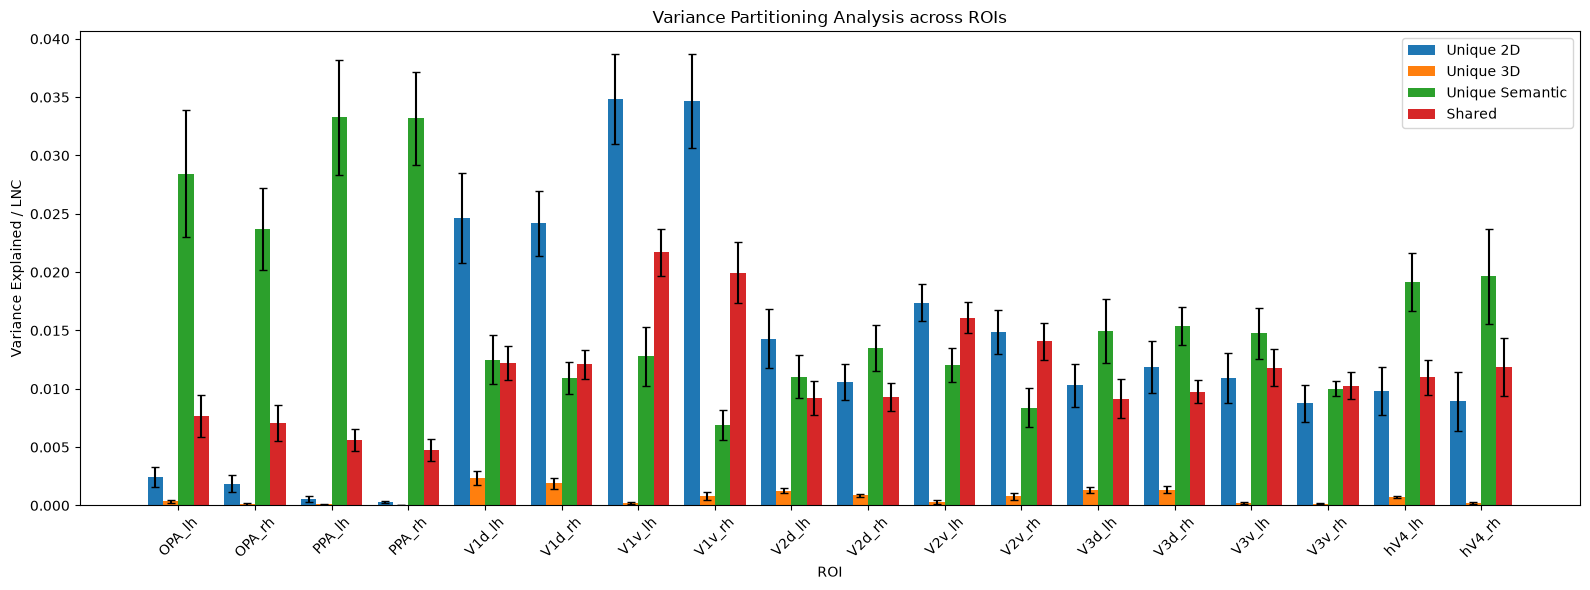

In [15]:
import matplotlib.pyplot as plt
import numpy as np

components = [
    "Unique_2D_LNC",
    "Unique_3D_LNC",
    "Unique_Semantic_LNC",
    "Shared_LNC"
]

labels = [
    "Unique 2D",
    "Unique 3D",
    "Unique Semantic",
    "Shared"
]

# Use LNC-normalized SEM for the error bars
error_columns = [
    "Unique_2D_SEM",
    "Unique_3D_SEM",
    "Unique_Semantic_SEM",
    "Shared_SEM"
]

x = np.arange(len(summary.index))

width = 0.2

plt.figure(figsize=(16, 6))

for i, (component, label, error_component) in enumerate(
    zip(
        components,
        labels,
        error_columns
    )
):

    plt.bar(
        x + (i - 1.5) * width,
        summary[component],
        width,
        yerr=summary[
            error_component
        ],
        capsize=3,
        label=label
    )

plt.xticks(
    x,
    summary.index,
    rotation=45
)

plt.ylabel(
    "Variance Explained / LNC"
)

plt.xlabel(
    "ROI"
)

plt.title(
    "Variance Partitioning Analysis across ROIs"
)

plt.legend()

plt.tight_layout()

plt.show()

In [16]:
df_vpa_all.to_csv(
    "UVP_all_ROIs_NSD.csv",
    index=False
)

print("Saved: UVP_all_ROIs_NSD.csv")

Saved: UVP_all_ROIs_NSD.csv


## scene only images

### Load the CSV

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.spatial.distance import squareform

category_file = "nsd_shared_categories.csv"

categories = pd.read_csv(category_file)

scene_categories = categories[
    categories["category"].str.lower() == "scenes"
].copy()

print("Number of scene images:", len(scene_categories))

data_2d = np.load(
    "2D_RDM_NSD.npz",
    allow_pickle=True
)

stimuli_name = np.asarray(
    data_2d["stimuli_name"]
)

rdm_stimuli = np.array(
    [str(x).zfill(5) for x in stimuli_name]
)

scene_nsd_ids = (
    scene_categories["nsd_id"]
    .astype(str)
    .str.zfill(5)
    .to_numpy()
)

stimulus_to_index = {
    nsd_id: i
    for i, nsd_id in enumerate(rdm_stimuli)
}

scene_indices = [
    stimulus_to_index[nsd_id]
    for nsd_id in scene_nsd_ids
]

scene_indices = np.asarray(
    scene_indices,
    dtype=int
)

print("Scene images:", len(scene_indices))
print("First 10 scene indices:", scene_indices[:10])

Number of scene images: 100
Scene images: 100
First 10 scene indices: [438 396 136 430 701 735 404 571  42 291]


In [13]:
# NSD subjects
subjects = [
    "subj01",
    "subj02",
    "subj03",
    "subj04",
    "subj05",
    "subj06",
    "subj07",
    "subj08"
]

# Output folder for scene-only brain RDMs
scene_brain_output_folder = Path(
    "NSD_scene_brain_RDMs"
)

scene_brain_output_folder.mkdir(
    exist_ok=True
)

print("Brain RDM source:")
print(nsd_path)

print("\nScene brain RDM output:")
print(scene_brain_output_folder)

Brain RDM source:
..\Algonauts23_shared_Net2Brain

Scene brain RDM output:
NSD_scene_brain_RDMs


In [15]:
for subject in subjects:

    print("\n" + "=" * 60)
    print("Processing:", subject)
    print("=" * 60)

    brain_rdm_folder = (
        nsd_path /
        subject /
        "rdms"
    )

    subject_output_folder = (
        scene_brain_output_folder /
        subject
    )

    subject_output_folder.mkdir(
        exist_ok=True
    )

    # Find all brain RDM files
    brain_rdm_files = sorted(
        brain_rdm_folder.glob("*.npy")
    )

    print(
        "Brain RDM files found:",
        len(brain_rdm_files)
    )

    for brain_file in brain_rdm_files:

        roi_name = brain_file.stem

        print(
            f"  Processing {roi_name}...",
            end=" "
        )

        brain_rdm = np.asarray(
            np.load(brain_file),
            dtype=float
        )

        brain_rdm_square = squareform(
            brain_rdm,
            checks=False
        )

        scene_brain_rdm_square = (
            brain_rdm_square[
                np.ix_(
                    scene_indices,
                    scene_indices
                )
            ]
        )

        scene_brain_rdm = squareform(
            scene_brain_rdm_square,
            checks=False
        )

        output_file = (
            subject_output_folder /
            f"Scene_{roi_name}.npz"
        )

        np.savez(
            output_file,
            rdm=scene_brain_rdm,
            stimuli_name=scene_nsd_ids
        )

        print(
            "saved"
        )

print("\nScene brain RDM extraction complete.")


Processing: subj01
Brain RDM files found: 37
  Processing EBA_lh_subj01... saved
  Processing EBA_rh_subj01... saved
  Processing FBA-1_lh_subj01... saved
  Processing FBA-1_rh_subj01... saved
  Processing FBA-2_rh_subj01... saved
  Processing FFA-1_lh_subj01... saved
  Processing FFA-1_rh_subj01... saved
  Processing FFA-2_rh_subj01... saved
  Processing hV4_lh_subj01... saved
  Processing hV4_rh_subj01... saved
  Processing mfs-words_lh_subj01... saved
  Processing OFA_lh_subj01... saved
  Processing OFA_rh_subj01... saved
  Processing OPA_lh_subj01... saved
  Processing OPA_rh_subj01... saved
  Processing OWFA_lh_subj01... saved
  Processing OWFA_rh_subj01... saved
  Processing PPA_lh_subj01... saved
  Processing PPA_rh_subj01... saved
  Processing RSC_lh_subj01... saved
  Processing RSC_rh_subj01... saved
  Processing V1d_lh_subj01... saved
  Processing V1d_rh_subj01... saved
  Processing V1v_lh_subj01... saved
  Processing V1v_rh_subj01... saved
  Processing V2d_lh_subj01... save

In [16]:
scene_model_rdm_files = {
    "2D": Path(
        "NSD_scene_model_RDMs/Scene_2D_RDM_NSD.npz"
    ),

    "3D": Path(
        "NSD_scene_model_RDMs/Scene_3D_RDM_NSD.npz"
    ),

    "Semantic": Path(
        "NSD_scene_model_RDMs/Scene_Semantic_RDM_NSD.npz"
    )
}

print("Scene model RDMs:")

for label, path in scene_model_rdm_files.items():
    print(
        label,
        "→",
        path
    )

Scene model RDMs:
2D → NSD_scene_model_RDMs\Scene_2D_RDM_NSD.npz
3D → NSD_scene_model_RDMs\Scene_3D_RDM_NSD.npz
Semantic → NSD_scene_model_RDMs\Scene_Semantic_RDM_NSD.npz


In [19]:
# Load scene-only model RDMs
scene_model_rdms = {}

for label, path in scene_model_rdm_files.items():

    data = np.load(
        path,
        allow_pickle=True
    )

    scene_model_rdms[label] = np.asarray(
        data["rdm"],
        dtype=float
    )

print("Loaded scene model RDMs:")

for label, rdm in scene_model_rdms.items():

    print(
        label,
        "→",
        rdm.shape
    )

Loaded scene model RDMs:
2D → (4950,)
3D → (4950,)
Semantic → (4950,)


### SCENE-ONLY RSA


In [24]:
from pathlib import Path

scene_visual_rdm_path = Path(
    "NSD_scene_visual_RDMs"
)

scene_ppa_rdm_path = Path(
    "NSD_scene_PPA_RDMs"
)

scene_opa_rdm_path = Path(
    "NSD_scene_OPA_RDMs"
)

scene_visual_rdm_path.mkdir(
    exist_ok=True
)

scene_ppa_rdm_path.mkdir(
    exist_ok=True
)

scene_opa_rdm_path.mkdir(
    exist_ok=True
)

print("Scene RSA folders created:")
print("Visual:", scene_visual_rdm_path)
print("PPA:", scene_ppa_rdm_path)
print("OPA:", scene_opa_rdm_path)

Scene RSA folders created:
Visual: NSD_scene_visual_RDMs
PPA: NSD_scene_PPA_RDMs
OPA: NSD_scene_OPA_RDMs


In [25]:
# ROIs FOR SCENE-ONLY RSA

visual_rois = [
    "V1d",
    "V1v",
    "V2d",
    "V2v",
    "V3d",
    "V3v",
    "hV4"
]

ppa_rois = [
    "PPA"
]

opa_rois = [
    "OPA"
]

print("Visual ROIs:", visual_rois)
print("PPA ROIs:", ppa_rois)
print("OPA ROIs:", opa_rois)

Visual ROIs: ['V1d', 'V1v', 'V2d', 'V2v', 'V3d', 'V3v', 'hV4']
PPA ROIs: ['PPA']
OPA ROIs: ['OPA']


In [27]:
# GROUP SCENE BRAIN RDMs
# subjects × 100 scenes × 100 scenes

import numpy as np
from scipy.spatial.distance import squareform

def create_scene_grouped_rdm(
    roi,
    hemisphere,
    output_folder
):

    subject_rdms = []

    for subject_num in range(1, 9):

        subject_name = f"subj{subject_num:02d}"

        file = (
            scene_brain_output_folder
            / subject_name
            / f"Scene_{roi}_{hemisphere}_{subject_name}.npz"
        )

        data = np.load(
            file,
            allow_pickle=True
        )

        condensed_rdm = np.asarray(
            data["rdm"],
            dtype=float
        )

        square_rdm = squareform(
            condensed_rdm,
            checks=False
        )

        subject_rdms.append(
            square_rdm
        )

    subject_rdms = np.stack(
        subject_rdms
    )

    output_file = (
        output_folder /
        f"{roi}_{hemisphere}.npz"
    )

    np.savez(
        output_file,
        rdm=subject_rdms
    )

    print(
        "Saved:",
        output_file,
        "Shape:",
        subject_rdms.shape
    )

for roi in visual_rois:

    for hemisphere in ["lh", "rh"]:

        create_scene_grouped_rdm(
            roi,
            hemisphere,
            scene_visual_rdm_path
        )

for roi in ppa_rois:

    for hemisphere in ["lh", "rh"]:

        create_scene_grouped_rdm(
            roi,
            hemisphere,
            scene_ppa_rdm_path
        )

for roi in opa_rois:

    for hemisphere in ["lh", "rh"]:

        create_scene_grouped_rdm(
            roi,
            hemisphere,
            scene_opa_rdm_path
        )


print("\nScene brain RSA files created.")

Saved: NSD_scene_visual_RDMs\V1d_lh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\V1d_rh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\V1v_lh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\V1v_rh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\V2d_lh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\V2d_rh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\V2v_lh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\V2v_rh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\V3d_lh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\V3d_rh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\V3v_lh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\V3v_rh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\hV4_lh.npz Shape: (8, 100, 100)
Saved: NSD_scene_visual_RDMs\hV4_rh.npz Shape: (8, 100, 100)
Saved: NSD_scene_PPA_RDMs\PPA_lh.npz Shape: (8, 100, 100)
Saved: NSD_scene_PPA_RDMs\PPA_rh.npz Shape: (8, 100, 100)
Saved: NSD_scene_OPA_RDMs\OPA_

In [30]:
from pathlib import Path
import shutil

scene_model_source_files = {
    "2D": Path(
        "NSD_scene_model_RDMs/Scene_2D_RDM_NSD.npz"
    ),

    "3D": Path(
        "NSD_scene_model_RDMs/Scene_3D_RDM_NSD.npz"
    ),

    "Semantic": Path(
        "NSD_scene_model_RDMs/Scene_Semantic_RDM_NSD.npz"
    )
}

scene_model_base_folder = Path(
    "NSD_scene_RSA_models"
)

scene_model_base_folder.mkdir(
    exist_ok=True
)


for model_name, source_file in scene_model_source_files.items():

    model_folder = (
        scene_model_base_folder /
        model_name
    )

    model_folder.mkdir(
        exist_ok=True
    )

    destination_file = (
        model_folder /
        "RDM_scene.npz"
    )

    shutil.copy2(
        source_file,
        destination_file
    )

    print(
        model_name,
        "->",
        destination_file
    )


print("\nScene model folders created.")

2D -> NSD_scene_RSA_models\2D\RDM_scene.npz
3D -> NSD_scene_RSA_models\3D\RDM_scene.npz
Semantic -> NSD_scene_RSA_models\Semantic\RDM_scene.npz

Scene model folders created.


In [31]:
scene_models = {
    "2D": "NSD_scene_RSA_models/2D",
    "3D": "NSD_scene_RSA_models/3D",
    "Semantic": "NSD_scene_RSA_models/Semantic"
}

print("Scene model folders:")

for model_name, model_folder in scene_models.items():

    print(
        model_name,
        "->",
        model_folder
    )

Scene model folders:
2D -> NSD_scene_RSA_models/2D
3D -> NSD_scene_RSA_models/3D
Semantic -> NSD_scene_RSA_models/Semantic


In [32]:
# RUN RSA FOR 2D, 3D AND SEMANTIC SCENE MODELS
from net2brain.evaluations.rsa import RSA

scene_visual_results = {}
scene_ppa_results = {}
scene_opa_results = {}

for model_name, model_rdm_folder in scene_models.items():

    print(
        f"\n========== {model_name} SCENE RSA =========="
    )

    # VISUAL CORTEX RSA
    visual_evaluation = RSA(
        model_rdm_folder,
        "./NSD_scene_visual_RDMs",
        model_name=f"Scene {model_name}"
    )

    df_visual = visual_evaluation.evaluate()

    scene_visual_results[model_name] = df_visual

    print(
        f"Visual RSA: {df_visual.shape}"
    )

    display(df_visual)

    # PPA RSA
    ppa_evaluation = RSA(
        model_rdm_folder,
        "./NSD_scene_PPA_RDMs",
        model_name=f"Scene {model_name}"
    )

    df_ppa = ppa_evaluation.evaluate()

    scene_ppa_results[model_name] = df_ppa

    print(
        f"PPA RSA: {df_ppa.shape}"
    )

    display(df_ppa)

    # OPA RSA
    opa_evaluation = RSA(
        model_rdm_folder,
        "./NSD_scene_OPA_RDMs",
        model_name=f"Scene {model_name}"
    )

    df_opa = opa_evaluation.evaluate()

    scene_opa_results[model_name] = df_opa

    print(
        f"OPA RSA: {df_opa.shape}"
    )

    display(df_opa)


print(
    "\n========== ALL SCENE RSA FINISHED =========="
)


========== 2D SCENE RSA ==========
Visual RSA: (14, 10)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) hV4_lh,(0) RDM_scene.npz,Scene 2D,0.005470,7.572797,"[0.01904877695548747, 0.009940525054416005, 0....",0.043959,0.002231,0.072231,0.233790
1,(1) hV4_rh,(0) RDM_scene.npz,Scene 2D,0.003386,5.256838,"[0.0023920355041624946, 0.001539684381816172, ...",0.005580,0.000859,0.064410,0.225143
2,(2) V1d_lh,(0) RDM_scene.npz,Scene 2D,0.019922,12.254762,"[0.023131676453531366, 0.0378804234311235, 0.0...",0.000508,0.003285,0.162564,0.322742
3,(3) V1d_rh,(0) RDM_scene.npz,Scene 2D,0.017287,10.563672,"[0.01873688893882934, 0.01885350205928615, 0.0...",0.000026,0.001784,0.163647,0.324688
4,(4) V1v_lh,(0) RDM_scene.npz,Scene 2D,0.019779,11.047555,"[0.022323603173309215, 0.018803866636517605, 0...",0.000013,0.001845,0.179039,0.341782
5,(5) V1v_rh,(0) RDM_scene.npz,Scene 2D,0.014859,8.313745,"[0.014082452511625595, 0.025114128435633203, 0...",0.000244,0.002172,0.178725,0.338538
6,(6) V2d_lh,(0) RDM_scene.npz,Scene 2D,0.006397,10.080095,"[0.01089098827424928, 0.019135670854756703, 0....",0.021477,0.002170,0.063461,0.223852
7,(7) V2d_rh,(0) RDM_scene.npz,Scene 2D,0.004542,5.314494,"[0.010193878676014779, 0.008911731007688538, 0...",0.008014,0.001239,0.085462,0.248463
8,(8) V2v_lh,(0) RDM_scene.npz,Scene 2D,0.009246,5.250828,"[0.012672058574476935, 0.01049644847366976, 0....",0.000028,0.000965,0.176089,0.338387
9,(9) V2v_rh,(0) RDM_scene.npz,Scene 2D,0.003928,2.665233,"[0.0030812854763727616, 0.0015886827830064168,...",0.007102,0.001046,0.147382,0.310780


PPA RSA: (2, 10)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) PPA_lh,(0) RDM_scene.npz,Scene 2D,0.004365,2.078466,"[0.006352615663801111, 0.010899223222669565, 0...",0.014405,0.001350,0.210014,0.364380
1,(1) PPA_rh,(0) RDM_scene.npz,Scene 2D,0.002693,1.077901,"[0.0024237118632980323, 0.003827921937306922, ...",0.008190,0.000738,0.249877,0.401335


OPA RSA: (2, 10)


...

PPA RSA: (2, 10)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) PPA_lh,(0) RDM_scene.npz,Scene Semantic,0.002278,1.084684,"[0.0006142540330156933, 2.609773190599162e-05,...",0.151577,0.001415,0.210014,0.364380
1,(1) PPA_rh,(0) RDM_scene.npz,Scene Semantic,0.002446,0.979020,"[2.7696363415677327e-07, 0.003720220616972509,...",0.043901,0.000997,0.249877,0.401335


OPA RSA: (2, 10)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) OPA_lh,(0) RDM_scene.npz,Scene Semantic,0.003684,2.951843,"[0.01120263525563943, 0.0100893868015305, 8.83...",0.052144,0.001577,0.124818,0.287810
1,(1) OPA_rh,(0) RDM_scene.npz,Scene Semantic,0.002805,2.057704,"[2.3181140260601355e-05, 0.0001180770836264929...",0.182617,0.001896,0.136316,0.299651



========== ALL SCENE RSA FINISHED ==========


In [33]:
# COMBINE ALL SCENE RSA RESULTS

scene_all_rsa_dfs = []

for model_name in scene_models:

    scene_all_rsa_dfs.append(
        scene_visual_results[model_name]
    )

    scene_all_rsa_dfs.append(
        scene_ppa_results[model_name]
    )

    scene_all_rsa_dfs.append(
        scene_opa_results[model_name]
    )

print(
    "Total scene RSA DataFrames:",
    len(scene_all_rsa_dfs)
)

Total scene RSA DataFrames: 9


### evaluate for scene only

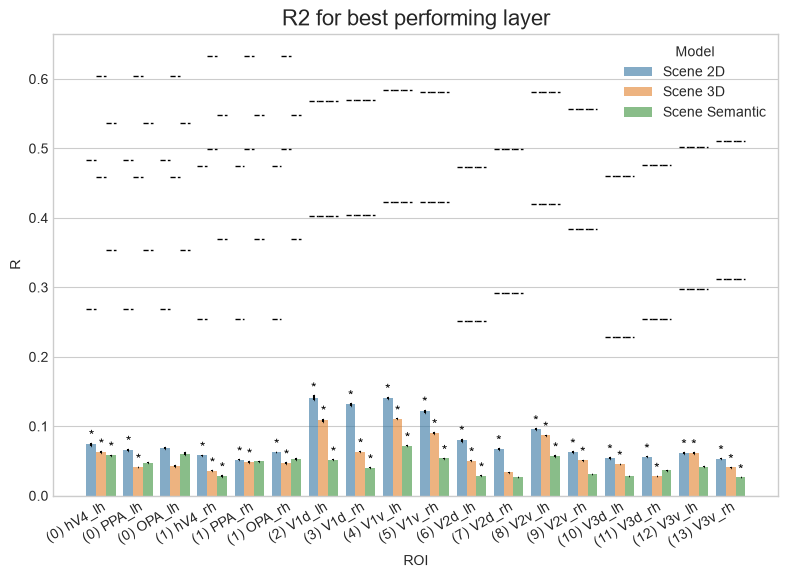

In [36]:
from net2brain.evaluations.plotting import Plotting

scene_plotter = Plotting(scene_all_rsa_dfs)

scene_results_dataframe = scene_plotter.plot(metric="R")

In [43]:
import pandas as pd

df_scene = scene_results_dataframe.copy()

# Clean model names
df_scene["Model"] = (
    df_scene["Model"]
    .str.replace("Scene ", "", regex=False)
)

# Assign ROI groups
def assign_roi_group(roi):

    roi = str(roi).lower()

    if "v1d" in roi or "v1v" in roi:
        return "V1"

    elif "v2d" in roi or "v2v" in roi:
        return "V2"

    elif "v3d" in roi or "v3v" in roi:
        return "V3"

    elif "hv4" in roi:
        return "V4"

    elif "ppa" in roi:
        return "PPA"

    elif "opa" in roi:
        return "OPA"

    return None


df_scene["ROI_Group"] = (
    df_scene["ROI"]
    .apply(assign_roi_group)
)

roi_order = ["V1", "V2", "V3", "V4", "PPA", "OPA"]
model_order = ["2D", "3D", "Semantic"]

df_scene["ROI_Group"] = pd.Categorical(
    df_scene["ROI_Group"],
    categories=roi_order,
    ordered=True
)

df_scene["Model"] = pd.Categorical(
    df_scene["Model"],
    categories=model_order,
    ordered=True
)

print("Scene dataframe:", df_scene.shape)

display(
    df_scene[
        ["ROI", "ROI_Group", "Model", "R"]
    ].head(20)
)

Scene dataframe: (54, 5)


,ROI,ROI_Group,Model,R
0,(0) hV4_lh,V4,2D,0.073959
1,(0) PPA_lh,PPA,2D,0.066069
2,(0) OPA_lh,OPA,2D,0.068872
3,(0) hV4_lh,V4,3D,0.062350
4,(0) PPA_lh,PPA,3D,0.041246
5,(0) OPA_lh,OPA,3D,0.042617
6,(0) hV4_lh,V4,Semantic,0.058410
7,(0) PPA_lh,PPA,Semantic,0.047728
8,(0) OPA_lh,OPA,Semantic,0.060700
9,(1) hV4_rh,V4,2D,0.058189


In [44]:
df_scene_summary = (
    df_scene
    .groupby(
        ["Model", "ROI_Group"],
        observed=True
    )["R"]
    .mean()
    .reset_index()
)

df_scene_summary["ROI_Group"] = pd.Categorical(
    df_scene_summary["ROI_Group"],
    categories=roi_order,
    ordered=True
)

df_scene_summary["Model"] = pd.Categorical(
    df_scene_summary["Model"],
    categories=model_order,
    ordered=True
)

df_scene_summary = (
    df_scene_summary
    .sort_values(["Model", "ROI_Group"])
    .reset_index(drop=True)
)

display(df_scene_summary)

,Model,ROI_Group,R
0,2D,V1,0.133790
1,2D,V2,0.076551
2,2D,V3,0.056311
3,2D,V4,0.066074
4,2D,PPA,0.058983
5,2D,OPA,0.065997
6,3D,V1,0.093348
7,3D,V2,0.055515
8,3D,V3,0.044159
9,3D,V4,0.049062


In [45]:
scene_comparison = df_scene_summary.pivot(
    index="ROI_Group",
    columns="Model",
    values="R"
).reindex(roi_order)

display(scene_comparison)

Model,2D,3D,Semantic
ROI_Group,,,
V1,0.133790,0.093348,0.054488
V2,0.076551,0.055515,0.036224
V3,0.056311,0.044159,0.033257
V4,0.066074,0.049062,0.043465
PPA,0.058983,0.044856,0.048594
OPA,0.065997,0.044820,0.056831


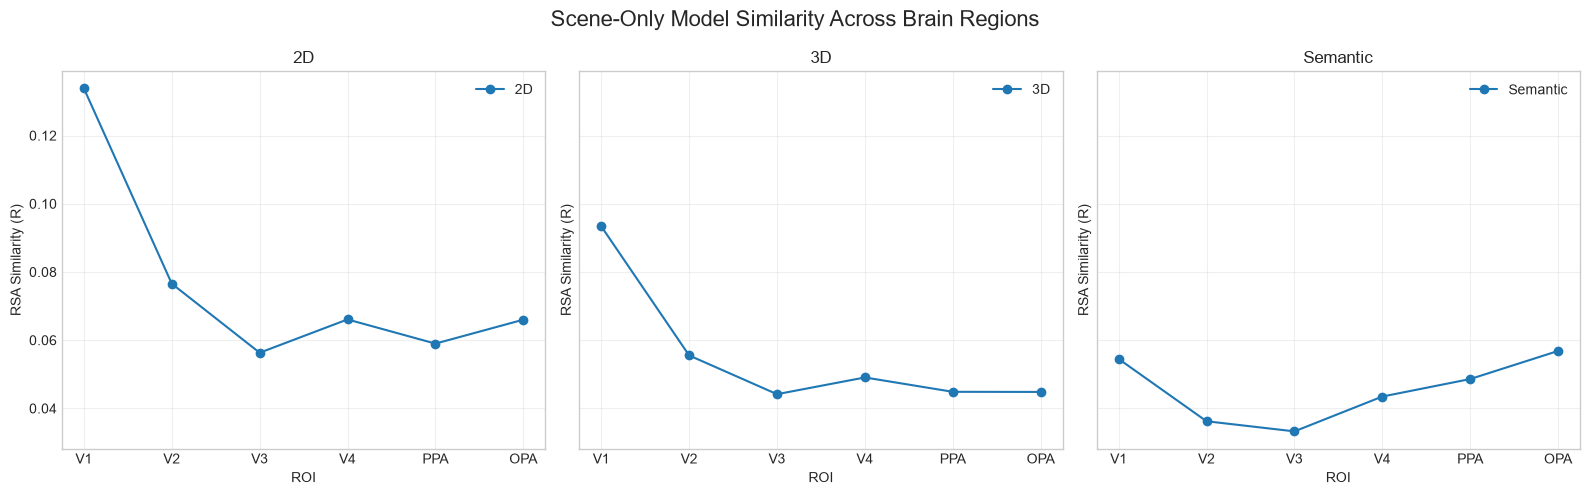

In [47]:
import matplotlib.pyplot as plt

models = [
    "2D",
    "3D",
    "Semantic"
]

roi_order = ["V1", "V2", "V3", "V4", "PPA", "OPA"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    sharey=True
)

axes = axes.flatten()

for ax, model_name in zip(axes, models):

    model_data = df_scene_summary[
        df_scene_summary["Model"] == model_name
    ]

    roi_data = (
        model_data
        .set_index("ROI_Group")
        .reindex(roi_order)
    )

    ax.plot(
        roi_order,
        roi_data["R"],
        marker="o",
        label=model_name
    )

    ax.set_title(model_name)

    ax.set_xlabel("ROI")
    ax.set_ylabel("RSA Similarity (R)")

    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(
    "Scene-Only Model Similarity Across Brain Regions",
    fontsize=16
)

plt.tight_layout()
plt.show()

### scene only VPA

In [48]:
import numpy as np
from pathlib import Path

scene_model_files = {
    "2D": Path("NSD_scene_model_RDMs/Scene_2D_RDM_NSD.npz"),
    "3D": Path("NSD_scene_model_RDMs/Scene_3D_RDM_NSD.npz"),
    "Semantic": Path("NSD_scene_model_RDMs/Scene_Semantic_RDM_NSD.npz")
}

for model_name, path in scene_model_files.items():

    data = np.load(path, allow_pickle=True)

    print("\n", model_name)
    print("Path:", path)
    print("Keys:", data.files)
    print("RDM shape:", data["rdm"].shape)

    if "stimuli_name" in data.files:
        print("Number of stimuli:", len(data["stimuli_name"]))


 2D
Path: NSD_scene_model_RDMs\Scene_2D_RDM_NSD.npz
Keys: ['rdm', 'stimuli_name']
RDM shape: (4950,)
Number of stimuli: 100

 3D
Path: NSD_scene_model_RDMs\Scene_3D_RDM_NSD.npz
Keys: ['rdm', 'stimuli_name']
RDM shape: (4950,)
Number of stimuli: 100

 Semantic
Path: NSD_scene_model_RDMs\Scene_Semantic_RDM_NSD.npz
Keys: ['rdm', 'stimuli_name']
RDM shape: (4950,)
Number of stimuli: 100


In [49]:
import numpy as np
from pathlib import Path

# Scene brain RDM folders
visual_rdm_folder = Path("NSD_scene_visual_RDMs")
ppa_rdm_folder = Path("NSD_scene_PPA_RDMs")
opa_rdm_folder = Path("NSD_scene_OPA_RDMs")

vpa_brain_folder = Path("VPA_brain_data_scene_NSD")
vpa_brain_folder.mkdir(exist_ok=True)

brain_rois = {}

# Visual ROIs
visual_rois = [
    "hV4_lh",
    "hV4_rh",
    "V1d_lh",
    "V1d_rh",
    "V1v_lh",
    "V1v_rh",
    "V2d_lh",
    "V2d_rh",
    "V2v_lh",
    "V2v_rh",
    "V3d_lh",
    "V3d_rh",
    "V3v_lh",
    "V3v_rh",
]

for roi in visual_rois:

    brain_rois[roi] = (
        visual_rdm_folder / f"{roi}.npz"
    )

# PPA
brain_rois["PPA_lh"] = (
    ppa_rdm_folder / "PPA_lh.npz"
)

brain_rois["PPA_rh"] = (
    ppa_rdm_folder / "PPA_rh.npz"
)

# OPA
brain_rois["OPA_lh"] = (
    opa_rdm_folder / "OPA_lh.npz"
)

brain_rois["OPA_rh"] = (
    opa_rdm_folder / "OPA_rh.npz"
)

# Convert each ROI to VPA format
brain_vpa_paths = {}

triu_idx = np.triu_indices(
    100,
    k=1
)

for roi_name, brain_path in brain_rois.items():

    print("\nProcessing:", roi_name)
    print("Path:", brain_path)

    if not brain_path.exists():
        raise FileNotFoundError(
            f"File not found: {brain_path.resolve()}"
        )

    brain_data = np.load(
        brain_path,
        allow_pickle=True
    )["rdm"]

    print(
        "Original shape:",
        brain_data.shape
    )

    assert brain_data.shape == (
        8,
        100,
        100
    ), (
        f"Unexpected shape for {roi_name}: "
        f"{brain_data.shape}"
    )
    # Square → condensed/vectorized
    brain_vectorized = brain_data[
        :,
        triu_idx[0],
        triu_idx[1]
    ]

    print(
        "Vectorized shape:",
        brain_vectorized.shape
    )

    assert brain_vectorized.shape == (
        8,
        4950
    )
    brain_vpa = brain_vectorized[
        :,
        np.newaxis,
        :
    ]

    print(
        "VPA shape:",
        brain_vpa.shape
    )

    assert brain_vpa.shape == (
        8,
        1,
        4950
    )

    output_path = (
        vpa_brain_folder
        / f"{roi_name}_vpa.npy"
    )

    np.save(
        output_path,
        brain_vpa
    )

    brain_vpa_paths[
        roi_name
    ] = str(output_path)

    print(
        "Saved:",
        output_path
    )


print("\nFinished.")
print(
    "Number of ROIs:",
    len(brain_vpa_paths)
)

print(
    "ROIs:",
    list(brain_vpa_paths.keys())
)


Processing: hV4_lh
Path: NSD_scene_visual_RDMs\hV4_lh.npz
Original shape: (8, 100, 100)
Vectorized shape: (8, 4950)
VPA shape: (8, 1, 4950)
Saved: VPA_brain_data_scene_NSD\hV4_lh_vpa.npy

Processing: hV4_rh
Path: NSD_scene_visual_RDMs\hV4_rh.npz
Original shape: (8, 100, 100)
Vectorized shape: (8, 4950)
VPA shape: (8, 1, 4950)
Saved: VPA_brain_data_scene_NSD\hV4_rh_vpa.npy

Processing: V1d_lh
Path: NSD_scene_visual_RDMs\V1d_lh.npz
Original shape: (8, 100, 100)
Vectorized shape: (8, 4950)
VPA shape: (8, 1, 4950)
Saved: VPA_brain_data_scene_NSD\V1d_lh_vpa.npy

Processing: V1d_rh
Path: NSD_scene_visual_RDMs\V1d_rh.npz
Original shape: (8, 100, 100)
Vectorized shape: (8, 4950)
VPA shape: (8, 1, 4950)
Saved: VPA_brain_data_scene_NSD\V1d_rh_vpa.npy

Processing: V1v_lh
Path: NSD_scene_visual_RDMs\V1v_lh.npz
Original shape: (8, 100, 100)
Vectorized shape: (8, 4950)
VPA shape: (8, 1, 4950)
Saved: VPA_brain_data_scene_NSD\V1v_lh_vpa.npy

Processing: V1v_rh
Path: NSD_scene_visual_RDMs\V1v_rh.npz
O

In [50]:
from net2brain.evaluations.variance_partitioning_analysis import VPA
import pandas as pd

# Scene-only model RDMs
independent_variables = [
    "NSD_scene_model_RDMs/Scene_2D_RDM_NSD.npz",
    "NSD_scene_model_RDMs/Scene_3D_RDM_NSD.npz",
    "NSD_scene_model_RDMs/Scene_Semantic_RDM_NSD.npz"
]

variable_names = [
    "2D",
    "3D",
    "Semantic"
]

all_vpa_results = []

# Run VPA for every ROI
for roi_name, dependent_variable_vpa in brain_vpa_paths.items():

    print(
        "\nRunning VPA:",
        roi_name
    )

    VPA_eval = VPA(
        dependent_variable_vpa,
        independent_variables,
        variable_names
    )

    df_vpa = VPA_eval.evaluate(
        average_models=True
    )

    df_vpa["ROI"] = roi_name

    all_vpa_results.append(
        df_vpa
    )

# Combine all ROIs
df_vpa_scene_all = pd.concat(
    all_vpa_results,
    ignore_index=True
)

print(
    "\nScene VPA shape:",
    df_vpa_scene_all.shape
)

display(
    df_vpa_scene_all.head(20)
)


Running VPA: hV4_lh

Running VPA: hV4_rh

Running VPA: V1d_lh

Running VPA: V1d_rh

Running VPA: V1v_lh

Running VPA: V1v_rh

Running VPA: V2d_lh

Running VPA: V2d_rh

Running VPA: V2v_lh

Running VPA: V2v_rh

Running VPA: V3d_lh

Running VPA: V3d_rh

Running VPA: V3v_lh

Running VPA: V3v_rh

Running VPA: PPA_lh

Running VPA: PPA_rh

Running VPA: OPA_lh

Running VPA: OPA_rh

Scene VPA shape: (288, 6)


,Variable,Description,Values,Significance,Color,ROI
0,R1,2D Influence,"[[0.025073141435999813], [0.01358930732686725]...",[0.037918250704860365],None,hV4_lh
1,R2,3D Influence,"[[0.012596009418380572], [0.01352424882165515]...",[0.03120522581080198],None,hV4_lh
2,R3,Semantic Influence,"[[0.015566442123414514], [0.008649815053282328...",[0.08166756074192376],None,hV4_lh
3,R12,Combined 2D and 3D Influence,"[[0.02627885231190108], [0.017818005922609514]...",[0.01582777292230044],None,hV4_lh
4,R13,Combined 2D and Semantic Influence,"[[0.032568346091045086], [0.017805150617004384...",[0.03130199351583307],None,hV4_lh
5,R23,Combined 3D and Semantic Influence,"[[0.018873786558949668], [0.015140107521146584...",[0.022789127362027577],None,hV4_lh
6,R123,Combined All Variables Influence,"[[0.032584647113285015], [0.01944182787641402]...",[0.01688717877559773],None,hV4_lh
7,y123,Shared Variance All,"[[0.00809925512918408], [0.004441935017458265]...",[0.2534536005564479],None,hV4_lh
8,y12,Shared Variance 2D and 3D,"[[0.003291043413295225], [0.00485361520845462]...",[0.04479803167365244],None,hV4_lh
9,y13,Shared Variance 2D and Semantic,"[[-2.8017660814838585e-05], [-7.96325431307032...",[0.5726003588376133],None,hV4_lh


In [51]:
for roi_name, path in brain_vpa_paths.items():

    data = np.load(path)

    print(roi_name)
    print("Path:", path)
    print("Shape:", data.shape)
    print()

hV4_lh
Path: VPA_brain_data_scene_NSD\hV4_lh_vpa.npy
Shape: (8, 1, 4950)

hV4_rh
Path: VPA_brain_data_scene_NSD\hV4_rh_vpa.npy
Shape: (8, 1, 4950)

V1d_lh
Path: VPA_brain_data_scene_NSD\V1d_lh_vpa.npy
Shape: (8, 1, 4950)

V1d_rh
Path: VPA_brain_data_scene_NSD\V1d_rh_vpa.npy
Shape: (8, 1, 4950)

V1v_lh
Path: VPA_brain_data_scene_NSD\V1v_lh_vpa.npy
Shape: (8, 1, 4950)

V1v_rh
Path: VPA_brain_data_scene_NSD\V1v_rh_vpa.npy
Shape: (8, 1, 4950)

V2d_lh
Path: VPA_brain_data_scene_NSD\V2d_lh_vpa.npy
Shape: (8, 1, 4950)

V2d_rh
Path: VPA_brain_data_scene_NSD\V2d_rh_vpa.npy
Shape: (8, 1, 4950)

V2v_lh
Path: VPA_brain_data_scene_NSD\V2v_lh_vpa.npy
Shape: (8, 1, 4950)

V2v_rh
Path: VPA_brain_data_scene_NSD\V2v_rh_vpa.npy
Shape: (8, 1, 4950)

V3d_lh
Path: VPA_brain_data_scene_NSD\V3d_lh_vpa.npy
Shape: (8, 1, 4950)

V3d_rh
Path: VPA_brain_data_scene_NSD\V3d_rh_vpa.npy
Shape: (8, 1, 4950)

V3v_lh
Path: VPA_brain_data_scene_NSD\V3v_lh_vpa.npy
Shape: (8, 1, 4950)

V3v_rh
Path: VPA_brain_data_scene_NSD\

In [52]:
import numpy as np
import pandas as pd

df_plot = df_vpa_scene_all.query(
    "Variable in ['y1', 'y2', 'y3', 'y123']"
).copy()

df_plot["Mean"] = df_plot["Values"].apply(
    lambda x: float(
        np.mean(
            np.asarray(x)
        )
    )
)

df_plot["SEM"] = df_plot["Values"].apply(
    lambda x:
        np.std(
            np.asarray(x),
            ddof=1
        )
        / np.sqrt(
            len(
                np.asarray(x)
            )
        )
)

name_map = {
    "y1": "Unique_2D",
    "y2": "Unique_3D",
    "y3": "Unique_Semantic",
    "y123": "Shared"
}

df_plot["Component"] = (
    df_plot["Variable"]
    .map(name_map)
)

display(
    df_plot.head()
)

,Variable,Description,Values,Significance,Color,ROI,Mean,SEM,Component
7,y123,Shared Variance All,"[[0.00809925512918408], [0.004441935017458265]...",[0.2534536005564479],None,hV4_lh,0.001443,0.001160,Shared
11,y1,Unique 2D,"[[0.013710860554335347], [0.004301720355267435...",[0.026053523113548385],None,hV4_lh,0.004364,0.001552,Unique_2D
12,y2,Unique 3D,"[[1.6301022239928464e-05], [0.0016366772594096...",[0.02091558361074765],None,hV4_lh,0.001081,0.000364,Unique_3D
13,y3,Unique Semantic,"[[0.006305794801383935], [0.001623821953804505...",[0.07970023086041657],None,hV4_lh,0.001762,0.000860,Unique_Semantic
23,y123,Shared Variance All,"[[0.0018829625417422502], [0.00064137902817051...",[0.10164016615084229],None,hV4_rh,0.000558,0.000296,Shared


In [53]:
# --------------------------------------------------
# Scene VPA summary with LNC normalization
# --------------------------------------------------

summary = df_plot.pivot(
    index="ROI",
    columns="Component",
    values="Mean"
)

# --------------------------------------------------
# Raw total variance explained
# --------------------------------------------------

summary["R2_full"] = (
    summary["Unique_2D"]
    + summary["Unique_3D"]
    + summary["Unique_Semantic"]
    + summary["Shared"]
)

# --------------------------------------------------
# Extract LNC
# --------------------------------------------------

lnc_data = (
    df_vpa_scene_all[
        df_vpa_scene_all["Variable"] == "LNC"
    ][
        ["ROI", "Values"]
    ]
    .copy()
)

lnc_data["LNC"] = lnc_data["Values"].apply(
    lambda x:
        float(
            np.asarray(x)
            .flatten()[0]
        )
)

lnc_data = (
    lnc_data[
        ["ROI", "LNC"]
    ]
    .drop_duplicates(
        subset="ROI"
    )
)

summary = summary.reset_index()

summary = summary.merge(
    lnc_data,
    on="ROI",
    how="left"
)

# --------------------------------------------------
# Divide each variance component by LNC
# --------------------------------------------------

summary["Unique_2D_LNC"] = (
    summary["Unique_2D"]
    / summary["LNC"]
)

summary["Unique_3D_LNC"] = (
    summary["Unique_3D"]
    / summary["LNC"]
)

summary["Unique_Semantic_LNC"] = (
    summary["Unique_Semantic"]
    / summary["LNC"]
)

summary["Shared_LNC"] = (
    summary["Shared"]
    / summary["LNC"]
)

# --------------------------------------------------
# Total variance explained / LNC
# --------------------------------------------------

summary["LNC_normalized_R2"] = (
    summary["R2_full"]
    / summary["LNC"]
)

summary = summary.set_index(
    "ROI"
)

display(
    summary[
        [
            "R2_full",
            "LNC",
            "LNC_normalized_R2",
            "Unique_2D_LNC",
            "Unique_3D_LNC",
            "Unique_Semantic_LNC",
            "Shared_LNC"
        ]
    ]
)

summary.to_csv(
    "VPA_summary_ROIs_scene_NSD_LNC_normalized.csv"
)

,R2_full,LNC,LNC_normalized_R2,Unique_2D_LNC,Unique_3D_LNC,Unique_Semantic_LNC,Shared_LNC
ROI,,,,,,,
OPA_lh,0.012741,0.124818,0.102079,0.051410,0.017514,0.021247,0.011909
OPA_rh,0.010195,0.136316,0.074792,0.036895,0.014786,0.015223,0.007888
PPA_lh,0.015442,0.210014,0.073530,0.040067,0.018829,0.011330,0.003303
PPA_rh,0.012154,0.249877,0.048641,0.024244,0.012293,0.009737,0.002366
V1d_lh,0.019882,0.162564,0.122300,0.089671,0.010800,0.003224,0.018605
V1d_rh,0.019519,0.163647,0.119273,0.103381,0.003676,0.004014,0.008202
V1v_lh,0.018952,0.179039,0.105853,0.055865,0.019594,0.002555,0.027839
V1v_rh,0.014721,0.178725,0.082368,0.047551,0.015108,0.001364,0.018345
V2d_lh,0.008997,0.063461,0.141773,0.111527,0.006785,0.007630,0.015831


In [54]:
# --------------------------------------------------
# LNC-normalized SEM
# --------------------------------------------------

lnc_lookup = (
    lnc_data
    .set_index("ROI")["LNC"]
    .to_dict()
)

df_plot["Values_LNC"] = df_plot.apply(
    lambda row:
        (
            np.asarray(
                row["Values"],
                dtype=float
            ).flatten()
            / lnc_lookup[row["ROI"]]
        ),
    axis=1
)

df_plot["SEM_LNC"] = df_plot[
    "Values_LNC"
].apply(
    lambda x:
        np.std(
            x,
            ddof=1
        )
        / np.sqrt(
            len(x)
        )
)

sem_lnc_summary = df_plot.pivot(
    index="ROI",
    columns="Component",
    values="SEM_LNC"
)

summary = summary.join(
    sem_lnc_summary,
    rsuffix="_SEM"
)

display(summary)

,Shared,Unique_2D,Unique_3D,Unique_Semantic,R2_full,LNC,Unique_2D_LNC,Unique_3D_LNC,Unique_Semantic_LNC,Shared_LNC,LNC_normalized_R2,Shared_SEM,Unique_2D_SEM,Unique_3D_SEM,Unique_Semantic_SEM
ROI,,,,,,,,,,,,,,,
OPA_lh,0.001486,0.006417,0.002186,0.002652,0.012741,0.124818,0.051410,0.017514,0.021247,0.011909,0.102079,0.005713,0.011775,0.007957,0.012551
OPA_rh,0.001075,0.005029,0.002016,0.002075,0.010195,0.136316,0.036895,0.014786,0.015223,0.007888,0.074792,0.003583,0.007501,0.006829,0.005773
PPA_lh,0.000694,0.008415,0.003954,0.002379,0.015442,0.210014,0.040067,0.018829,0.011330,0.003303,0.073530,0.003478,0.009407,0.005053,0.005395
PPA_rh,0.000591,0.006058,0.003072,0.002433,0.012154,0.249877,0.024244,0.012293,0.009737,0.002366,0.048641,0.002972,0.003200,0.004838,0.003246
V1d_lh,0.003025,0.014577,0.001756,0.000524,0.019882,0.162564,0.089671,0.010800,0.003224,0.018605,0.122300,0.003098,0.018010,0.003835,0.000956
V1d_rh,0.001342,0.016918,0.000602,0.000657,0.019519,0.163647,0.103381,0.003676,0.004014,0.008202,0.119273,0.002891,0.011987,0.001899,0.001058
V1v_lh,0.004984,0.010002,0.003508,0.000458,0.018952,0.179039,0.055865,0.019594,0.002555,0.027839,0.105853,0.003243,0.007599,0.003335,0.001120
V1v_rh,0.003279,0.008499,0.002700,0.000244,0.014721,0.178725,0.047551,0.015108,0.001364,0.018345,0.082368,0.003322,0.007373,0.004044,0.000463
V2d_lh,0.001005,0.007078,0.000431,0.000484,0.008997,0.063461,0.111527,0.006785,0.007630,0.015831,0.141773,0.006526,0.037945,0.004634,0.002569


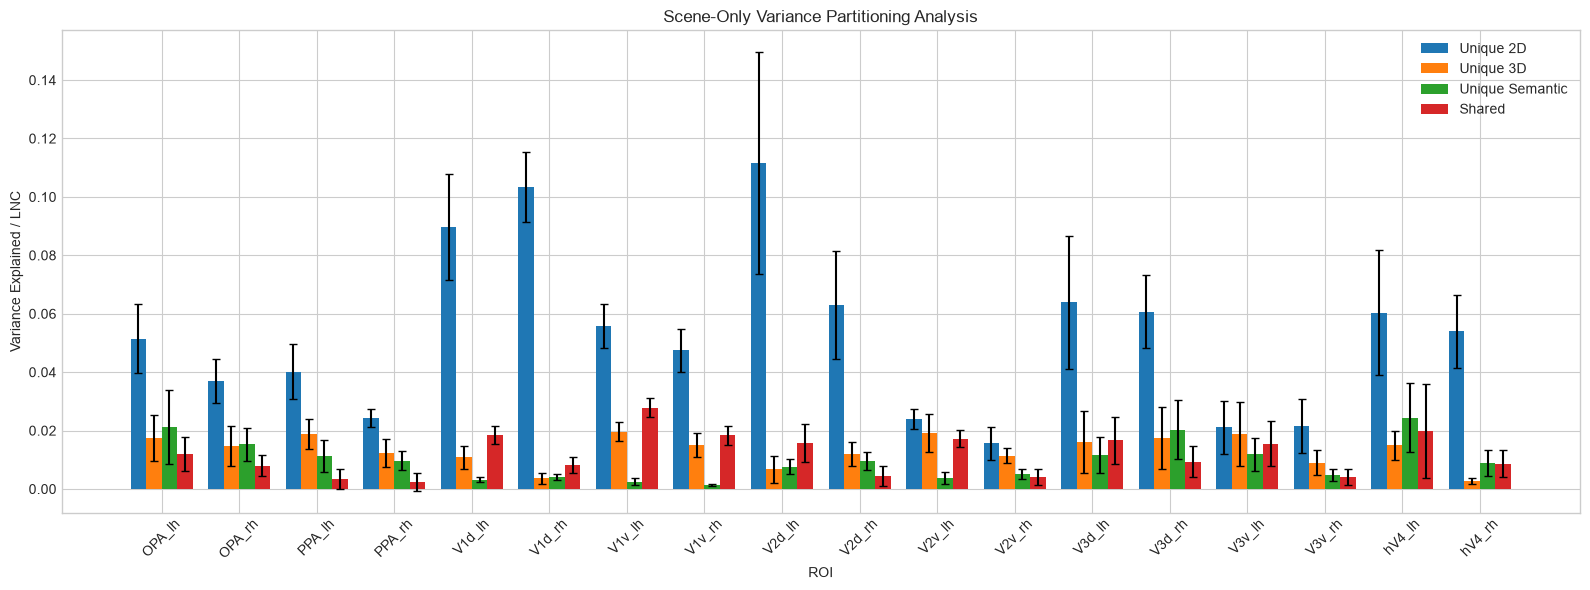

In [55]:
import matplotlib.pyplot as plt
import numpy as np

components = [
    "Unique_2D_LNC",
    "Unique_3D_LNC",
    "Unique_Semantic_LNC",
    "Shared_LNC"
]

labels = [
    "Unique 2D",
    "Unique 3D",
    "Unique Semantic",
    "Shared"
]

error_columns = [
    "Unique_2D_SEM",
    "Unique_3D_SEM",
    "Unique_Semantic_SEM",
    "Shared_SEM"
]

x = np.arange(
    len(summary.index)
)

width = 0.2

plt.figure(
    figsize=(16, 6)
)

for i, (
    component,
    label,
    error_component
) in enumerate(
    zip(
        components,
        labels,
        error_columns
    )
):

    plt.bar(
        x + (i - 1.5) * width,
        summary[component],
        width,
        yerr=summary[
            error_component
        ],
        capsize=3,
        label=label
    )

plt.xticks(
    x,
    summary.index,
    rotation=45
)

plt.ylabel(
    "Variance Explained / LNC"
)

plt.xlabel(
    "ROI"
)

plt.title(
    "Scene-Only Variance Partitioning Analysis"
)

plt.legend()

plt.tight_layout()

plt.show()

In [62]:
df_vpa_scene_all.to_csv(
    "VPA_all_ROIs_scene_NSD.csv",
    index=False
)

print(
    "Saved: VPA_all_ROIs_scene_NSD.csv"
)

Saved: VPA_all_ROIs_scene_NSD.csv
